# Sequence-Only Baselines for Prefix-Level Session Classification: Minimal Input, Comparative Diagnostics, and Performance Ceiling

Experiment establishes a performance baseline for early session-type classification using strictly minimal input: only the sequence of `event_name` tokens. Two simple probabilistic baselines (Heuristic and Markov(1)) and a sequential transformer model (SASRec) are compared under a unified evaluation protocol: data pipeline and labeling in Sections 1-3, temporal split and prefix construction in Sections 4-5, baseline models in Section 6, SASRec training in Section 7. Quantitative error analysis and diagnostics follow in Section 8; artifact documentation in Section 9.

**Dataset:** BigQuery public GA4 e-commerce sample - 360,129 sessions, 4,295,584 events. Sessions are labeled into 4 classes (Buyer, Intent, Researcher, Browser) via a rule-based hierarchy defined in Section 3.

**Key result:** With session-level class weights (computed on train sessions), SASRec achieved mean test Macro-F1 0.4176 ± 0.0011 across seeds (best-seed test Macro-F1 0.4187), outperforming the Heuristic (0.3761) and Markov(1) (0.3186) baselines. Buyer and Intent remain the hardest classes across models. Results define the performance ceiling of sequence-only models and provide the reference point for Experiment 2.

# 1. Introduction and Data


In [ ]:
# -- Imports and setup --

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
from collections import Counter
from google.colab import auth
from google.cloud import bigquery

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

# authenticate Colab session to access BigQuery public datasets
auth.authenticate_user()
client = bigquery.Client()

## 1.1 Data Source and Definitions

> **Note:** We intentionally restrict the input representation to session-level sequences of `event_name` (with identifiers and timestamps only) and drop all event parameters/items. This keeps the task definition simple and fully reproducible, ensures fair comparability between Markov(1) and SASRec under the same token space, and reduces both feature-space complexity and potential target leakage through rich GA4 fields.

- **Source:** GA4 public dataset in BigQuery, `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
- **Grain:** one row = one event
- **Session key:** `(user_pseudo_id, ga_session_id)` where `ga_session_id` is extracted from `event_params` in the original GA4 schema
- **Event order:** sort by `event_timestamp` within each session
- **session_end_time:** `max(event_timestamp)` per session
- **session_length:** number of events (rows) per session

In [ ]:
PROJECT_ID = "ga4sb-487512"
client = bigquery.Client(project=PROJECT_ID)

# public GA4 sample dataset — daily sharded tables events_YYYYMMDD
BQ_TABLE = "bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*"

print(f"Project: {PROJECT_ID}")
print(f"Source table: {BQ_TABLE}")

Project: ga4sb-487512
Source table: bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*


In [ ]:
# -- 1.1 Query required fields from BigQuery --

query = """
SELECT
    user_pseudo_id,
    (SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'ga_session_id') AS ga_session_id,
    event_timestamp,
    event_name,
    event_date
FROM
    `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
"""

prepared_data = client.query(query).to_dataframe()

print(f"Rows: {prepared_data.shape[0]:,}")
print(f"Columns: {prepared_data.shape[1]}")
print()
print(prepared_data.dtypes)
print()
print(prepared_data.head())

Rows: 4,295,584
Columns: 5

user_pseudo_id     object
ga_session_id       Int64
event_timestamp     Int64
event_name         object
event_date         object
dtype: object

       user_pseudo_id  ga_session_id   event_timestamp         event_name  \
0  4792087.7875785224     3985166001  1608952087447077  add_shipping_info   
1  5798842.3922639602      242077351  1608945734405030   add_payment_info   
2  6135662.0853737840     8967239508  1608972528952533  add_shipping_info   
3  6604560.8893864486     3823040339  1609012665871236  add_shipping_info   
4  6624764.2030956955     3108132284  1608980109919309  add_shipping_info   

  event_date  
0   20201226  
1   20201226  
2   20201226  
3   20201226  
4   20201226  


**Result:** 4,295,584 events loaded directly from BigQuery with 5 required fields. Types preserved natively (`Int64` for identifiers and timestamps, `object` for strings).

## 1.2 Quality Checks

Basic QC before session construction: null rates, duplicates, and date/timestamp range validation.

In [ ]:
# -- 1.2 Null rates per column --

print("Null counts:")
print(prepared_data.isnull().sum())

Null counts:
user_pseudo_id     0
ga_session_id      0
event_timestamp    0
event_name         0
event_date         0
dtype: int64


In [ ]:
# -- 1.2 Duplicates and date/timestamp range --

n_dupes = prepared_data.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes:,}")
print()

print(f"event_date range: {prepared_data['event_date'].min()} — {prepared_data['event_date'].max()}")
print(f"Unique dates: {prepared_data['event_date'].nunique()}")
print()

ts_min = prepared_data["event_timestamp"].min()
ts_max = prepared_data["event_timestamp"].max()
print(f"event_timestamp range: {ts_min} — {ts_max}")

Exact duplicate rows: 0

event_date range: 20201101 — 20210131
Unique dates: 92

event_timestamp range: 1604188804579566 — 1612137595412363


**Result:** No nulls, no duplicates. Date range: 2020-11-01 to 2021-01-31 (92 days). Timestamp range consistent with dates. Rows: 4,295,584.

## 1.3 Session Key and Event Ordering

Construct composite session key `(user_pseudo_id, ga_session_id)` and sort all events by `event_timestamp` within each session.

In [ ]:
# -- 1.3 Build session_key and sort events --

prepared_data["session_key"] = (
    prepared_data["user_pseudo_id"] + "_" + prepared_data["ga_session_id"].astype(str)
)

prepared_data = prepared_data.sort_values(
    ["session_key", "event_timestamp"]
).reset_index(drop=True)

print(f"Unique sessions: {prepared_data['session_key'].nunique():,}")
print(f"Unique users: {prepared_data['user_pseudo_id'].nunique():,}")
print()
print(prepared_data.head(10))

Unique sessions: 360,129
Unique users: 270,154

          user_pseudo_id  ga_session_id   event_timestamp       event_name  \
0    10001363.4360935308     5983736405  1607746277508078      first_visit   
1    10001363.4360935308     5983736405  1607746277508078        page_view   
2    10001363.4360935308     5983736405  1607746277508078    session_start   
3    10001363.4360935308     5983736405  1607746292809866  user_engagement   
4  1000223163.8035209215     6063162078  1610044534089387      first_visit   
5  1000223163.8035209215     6063162078  1610044534089387        page_view   
6  1000223163.8035209215     6063162078  1610044534089387    session_start   
7  1000223163.8035209215     6063162078  1610044539094280        page_view   
8  1000223163.8035209215     6063162078  1610044539094280           scroll   
9  1000223163.8035209215     6063162078  1610044544561794  user_engagement   

  event_date                       session_key  
0   20201212    10001363.4360935308_59837364

**Result:** 360,129 unique sessions from 270,154 unique users. Events sorted by `event_timestamp` within each session. Note: events with identical timestamps within a session have arbitrary order — a known limitation of GA4 event logging.

## 1.4 Session-Level Table

Aggregate events into session-level summary: `session_end_time` and `session_length`. Save both event-level and session-level tables locally to avoid re-querying BigQuery on notebook restarts.

In [ ]:
# -- 1.4 Build session-level table --

sessions = prepared_data.groupby("session_key").agg(
    user_pseudo_id=("user_pseudo_id", "first"),
    session_end_time=("event_timestamp", "max"),
    session_length=("event_name", "count"),
).reset_index()

print(f"Sessions: {sessions.shape[0]:,}")
print()
print(sessions.head())
print()
print(sessions["session_length"].describe())

Sessions: 360,129

                        session_key         user_pseudo_id  session_end_time  \
0    10001363.4360935308_5983736405    10001363.4360935308  1607746292809866   
1  1000223163.8035209215_6063162078  1000223163.8035209215  1610044544561794   
2     1000299.7413851356_3338398581     1000299.7413851356  1611140705779925   
3     1000300.3223254235_3614622791     1000300.3223254235  1604497410570448   
4     1000300.3223254235_9350310735     1000300.3223254235  1604481678760672   

   session_length  
0               4  
1               6  
2               5  
3               2  
4               4  

count    360129.000000
mean         11.927904
std          26.472722
min           1.000000
25%           4.000000
50%           5.000000
75%           9.000000
max        1007.000000
Name: session_length, dtype: float64


In [ ]:
# -- 1.4 Save to local CSV for restarts --

prepared_data.to_csv("event_level.csv", index=False)
sessions.to_csv("session_level.csv", index=False)

print(f"Saved event_level.csv: {prepared_data.shape[0]:,} rows")
print(f"Saved session_level.csv: {sessions.shape[0]:,} rows")

Saved event_level.csv: 4,295,584 rows
Saved session_level.csv: 360,129 rows


**Result:** 360,129 sessions built. Median session length: 5 events, mean: ~12, max: 1,007. Both event-level and session-level tables saved locally (`event_level.csv`, `session_level.csv`).

**Section 1 Summary:** Loaded 4,295,584 events (5 fields) directly from BigQuery public dataset. No nulls, no duplicates, date range 2020-11-01 to 2021-01-31 (92 days). Constructed 360,129 sessions from 270,154 users. Median session length 5 events, mean ~12, max 1,007. Event-level and session-level tables saved locally for reuse.

# 2. Exploratory Analysis for Session-Level Classification

This section performs a structured exploratory analysis of the event- and session-level data to characterize behavioral distributions relevant to the downstream session-level classification task. Specifically, we examine event frequency patterns, session length distributions, and the occurrence of purchase-, cart-, and checkout-related events that define the hierarchical labeling scheme introduced later.

For reproducibility and robustness to notebook restarts, we reload the event- and session-level datasets from the local CSV files generated in Section 1.

In [ ]:
# -- 2.0 Load data from local CSV --

prepared_data = pd.read_csv("event_level.csv")
sessions = pd.read_csv("session_level.csv")

print(f"Events: {prepared_data.shape[0]:,} rows, {prepared_data.shape[1]} columns")
print(f"Sessions: {sessions.shape[0]:,} rows, {sessions.shape[1]} columns")

Events: 4,295,584 rows, 6 columns
Sessions: 360,129 rows, 4 columns


**Result:** Event-level (4,295,584 rows) and session-level (360,129 rows) datasets reloaded from local CSV.

## 2.1 Event Name Distribution

This subsection analyzes the frequency distribution of event_name values to characterize the dominant behavioral actions in the dataset and assess their relative contribution to session trajectories used in the downstream classification task.

In [ ]:
# -- 2.1 Event name frequency distribution --

event_counts = prepared_data["event_name"].value_counts()

print(f"Unique event types: {len(event_counts)}")
print()
print(event_counts)

Unique event types: 17

event_name
page_view              1350428
user_engagement        1058721
scroll                  493072
view_item               386068
session_start           354970
first_visit             257462
view_promotion          190104
add_to_cart              58543
begin_checkout           38757
select_item              31007
view_search_results      26172
add_shipping_info        19722
add_payment_info         13899
select_promotion          9450
purchase                  5692
click                     1446
view_item_list              71
Name: count, dtype: int64


**Result:** 17 unique event types. Dominant events are navigational (page_view 1.35M, user_engagement 1.06M, scroll 493K). Product-interaction events from the allowlist: view_item (386K), select_item (31K), view_item_list (71). Cart/checkout funnel: add_to_cart (58.5K), begin_checkout (38.8K), add_shipping_info (19.7K), add_payment_info (13.9K). Purchase events: 5,692 — relatively rare at event level.

## 2.2 Session Length Distribution

This subsection analyzes the distribution of session_length (number of events per session) and reports key percentiles (p50, p90, p95, p99). These statistics are used to define the Tmax threshold applied during prefix construction in subsequent modeling stages.

In [ ]:
# -- 2.2 Session length distribution --

length_stats = sessions["session_length"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

print(length_stats)

count    360129.000000
mean         11.927904
std          26.472722
min           1.000000
50%           5.000000
90%          22.000000
95%          39.000000
99%         125.000000
max        1007.000000
Name: session_length, dtype: float64


**Result:** Median session length is 5 events, mean ~12, indicating right-skewed distribution. Key percentiles: p90 = 22, p95 = 39, p99 = 125, max = 1,007. Note: p95 is computed on all sessions here for orientation; final Tmax is computed on train split only in Section 5.

## 2.3 Key E-commerce Event Prevalence

This subsection computes session-level occurrence rates of purchase, cart/checkout-related events, and product-interaction events. The objective is to characterize the behavioral signals that define the hierarchical labeling scheme prior to formal class assignment.

In [ ]:
# -- 2.3 Key e-commerce event prevalence at session level --

# Define event groups
purchase_events = {"purchase"}
cart_checkout_events = {"add_to_cart", "begin_checkout", "add_shipping_info", "add_payment_info"}
product_interaction_events = {"view_item", "view_item_list", "select_item"}

# Flag events by group
prepared_data["is_purchase"] = prepared_data["event_name"].isin(purchase_events)
prepared_data["is_cart_checkout"] = prepared_data["event_name"].isin(cart_checkout_events)
prepared_data["is_product_interaction"] = prepared_data["event_name"].isin(product_interaction_events)

# Aggregate to session level
session_flags = prepared_data.groupby("session_key").agg(
    has_purchase=("is_purchase", "any"),
    has_cart_checkout=("is_cart_checkout", "any"),
    has_product_interaction=("is_product_interaction", "any"),
    product_interaction_count=("is_product_interaction", "sum")
).reset_index()

n_sessions = len(session_flags)

print(f"Sessions with purchase: {session_flags['has_purchase'].sum():,} ({session_flags['has_purchase'].mean():.2%})")
print(f"Sessions with cart/checkout: {session_flags['has_cart_checkout'].sum():,} ({session_flags['has_cart_checkout'].mean():.2%})")
print(f"Sessions with product interaction: {session_flags['has_product_interaction'].sum():,} ({session_flags['has_product_interaction'].mean():.2%})")

Sessions with purchase: 4,848 (1.35%)
Sessions with cart/checkout: 20,335 (5.65%)
Sessions with product interaction: 77,086 (21.41%)


**Result:** Purchase sessions: 4,848 (1.35%) — confirms Buyer will be a rare class. Cart/checkout sessions: 20,335 (5.65%). Sessions with at least one product interaction: 77,086 (21.41%). The remaining ~79% of sessions have no product interactions from the allowlist.

**Section 2 Summary:** 17 unique event types dominated by navigational events (page_view, user_engagement, scroll). Session length is right-skewed: median 5, p95 = 39 (computed on all sessions; final Tmax will be computed on train split only in Section 5). Purchase sessions are rare (1.35%), cart/checkout sessions 5.65%, product-interaction sessions 21.41%. Class imbalance expected: Buyer will be the minority class.

# 3. Session Labeling

This section assigns each session to one of four mutually exclusive classes using a fixed priority hierarchy (applied top-down):

- **Buyer**: session contains `purchase`
- **Intent**: no purchase, but has at least one of: `add_to_cart`, `begin_checkout`, `add_shipping_info`, `add_payment_info`
- **Researcher**: no purchase, no cart/checkout events, but `product_interactions_count ≥ 3`
- **Browser**: all remaining sessions

Product interactions allowlist: `view_item`, `view_item_list`, `select_item`.

## 3.1 Class Assignment

Apply the hierarchical labeling rules to assign each session to exactly one class. The `session_flags` dataframe from Section 2.3 already contains the required flags (`has_purchase`, `has_cart_checkout`, `product_interaction_count`).

In [ ]:
# -- 3.1 Apply hierarchical labeling rules --

def assign_class(row):
    if row["has_purchase"]:
        return "Buyer"
    elif row["has_cart_checkout"]:
        return "Intent"
    elif row["product_interaction_count"] >= 3:
        return "Researcher"
    else:
        return "Browser"

session_flags["session_class"] = session_flags.apply(assign_class, axis=1)

class_counts = session_flags["session_class"].value_counts()
class_pcts = session_flags["session_class"].value_counts(normalize=True) * 100

print("Class distribution:")
for cls in ["Buyer", "Intent", "Researcher", "Browser"]:
    print(f"  {cls}: {class_counts[cls]:,} ({class_pcts[cls]:.2f}%)")

Class distribution:
  Buyer: 4,848 (1.35%)
  Intent: 15,490 (4.30%)
  Researcher: 19,943 (5.54%)
  Browser: 319,848 (88.81%)


In [ ]:
# -- 3.1 Labeling validation checks --

# Check 1: No sessions without class
null_classes = session_flags["session_class"].isnull().sum()
print(f"Sessions without class: {null_classes}")

# Check 2: Total matches expected
total_labeled = len(session_flags)
print(f"Total labeled sessions: {total_labeled:,} (expected 360,129)")

# Check 3: Each class is mutually exclusive (verify hierarchy logic)
# Buyer should have purchase
buyer_check = session_flags[session_flags["session_class"] == "Buyer"]["has_purchase"].all()
# Intent should have cart/checkout but no purchase
intent_mask = session_flags["session_class"] == "Intent"
intent_check = (session_flags[intent_mask]["has_cart_checkout"].all() and
                ~session_flags[intent_mask]["has_purchase"].any())
# Researcher should have product_interaction_count >= 3, no purchase, no cart/checkout
researcher_mask = session_flags["session_class"] == "Researcher"
researcher_check = ((session_flags[researcher_mask]["product_interaction_count"] >= 3).all() and
                    ~session_flags[researcher_mask]["has_purchase"].any() and
                    ~session_flags[researcher_mask]["has_cart_checkout"].any())

print(f"Buyer rule valid: {buyer_check}")
print(f"Intent rule valid: {intent_check}")
print(f"Researcher rule valid: {researcher_check}")

Sessions without class: 0
Total labeled sessions: 360,129 (expected 360,129)
Buyer rule valid: True
Intent rule valid: True
Researcher rule valid: True


**Result:**

- Buyer: 4,848 (1.35%)
- Intent: 15,490 (4.30%)
- Researcher: 19,943 (5.54%)
- Browser: 319,848 (88.81%)

Validation passed: all 360,129 sessions labeled, no nulls, hierarchy rules verified. Substantial class imbalance with Browser dominating (~ 89%) and Buyer as the rarest class (~ 1%).

## 3.2 Researcher Threshold Sanity Check

Examine the distribution of `product_interaction_count` for sessions without purchase and without cart/checkout events to validate that the threshold ≥ 3 meaningfully separates active researchers from casual browsers. Note: final validation will be repeated on train split only.

In [ ]:
# -- 3.2 Researcher threshold sanity check --

# Sessions without purchase and without cart/checkout (candidates for Researcher vs Browser)
no_purchase_no_cart = session_flags[
    ~session_flags["has_purchase"] & ~session_flags["has_cart_checkout"]
]

print(f"Sessions without purchase/cart/checkout: {len(no_purchase_no_cart):,}")
print()

# Distribution of product_interaction_count
pi_dist = no_purchase_no_cart["product_interaction_count"].value_counts().sort_index()
print("product_interaction_count distribution:")
print(pi_dist.head(10))
print()

# Cumulative view around threshold
for threshold in [1, 2, 3, 4, 5]:
    below = (no_purchase_no_cart["product_interaction_count"] < threshold).sum()
    at_or_above = (no_purchase_no_cart["product_interaction_count"] >= threshold).sum()
    print(f"Threshold {threshold}: below={below:,}, at_or_above={at_or_above:,} ({at_or_above/len(no_purchase_no_cart):.2%})")

Sessions without purchase/cart/checkout: 339,791

product_interaction_count distribution:
product_interaction_count
0    282748
1     27273
2      9827
3      6339
4      3679
5      2204
6      1674
7      1099
8       909
9       669
Name: count, dtype: int64

Threshold 1: below=282,748, at_or_above=57,043 (16.79%)
Threshold 2: below=310,021, at_or_above=29,770 (8.76%)
Threshold 3: below=319,848, at_or_above=19,943 (5.87%)
Threshold 4: below=326,187, at_or_above=13,604 (4.00%)
Threshold 5: below=329,866, at_or_above=9,925 (2.92%)


> **Note**: The Researcher threshold is fixed a priori at product_interaction_count ≥ 3 based on the task definition (sessions with more than 1–2 product interactions). The analysis in Section 3.2 is a confirmatory sanity check and is not used to tune or choose the threshold.

**Result:** 339,791 sessions without purchase/cart/checkout. The distribution is heavily skewed: 83% have zero product interactions. A threshold of ≥3 captures 19,943 sessions (5.87%) as Researcher. This threshold excludes incidental interactions (1–2 events) while retaining sessions with repeated product engagement, resulting in a compact and behaviorally distinct subgroup.

## 3.3 Merge Labels to Session Table

Merge class labels and rationale features (flags and counts) into the main session-level table for downstream use. Save updated table to CSV.

In [ ]:
# -- 3.3 Merge labels to session table --

sessions = sessions.merge(
    session_flags[["session_key", "has_purchase", "has_cart_checkout",
                   "has_product_interaction", "product_interaction_count", "session_class"]],
    on="session_key",
    how="left"
)

print(f"Sessions: {len(sessions):,} rows, {sessions.shape[1]} columns")
print()
print(sessions.head())

Sessions: 360,129 rows, 9 columns

                        session_key  user_pseudo_id  session_end_time  \
0    10001363.4360935308_5983736405    1.000136e+07  1607746292809866   
1  1000223163.8035209215_6063162078    1.000223e+09  1610044544561794   
2     1000299.7413851356_3338398581    1.000300e+06  1611140705779925   
3     1000300.3223254235_3614622791    1.000300e+06  1604497410570448   
4     1000300.3223254235_9350310735    1.000300e+06  1604481678760672   

   session_length  has_purchase  has_cart_checkout  has_product_interaction  \
0               4         False              False                    False   
1               6         False              False                    False   
2               5         False              False                    False   
3               2         False              False                    False   
4               4         False              False                    False   

   product_interaction_count session_class  
0     

In [ ]:
# -- 3.3 Save updated session table --

sessions.to_csv("session_level.csv", index=False)

print(f"Saved session_level.csv: {len(sessions):,} rows, {sessions.shape[1]} columns")

Saved session_level.csv: 360,129 rows, 9 columns


**Result:** Session table now contains 9 columns: session_key, user_pseudo_id, session_end_time, session_length, has_purchase, has_cart_checkout, has_product_interaction, product_interaction_count, session_class. Updated CSV saved.

**Section 3 Summary:**

- Applied hierarchical labeling (Buyer > Intent > Researcher > Browser) to all 360,129 sessions
- Class distribution: Buyer 1.35%, Intent 4.30%, Researcher 5.54%, Browser 88.81%
- Validation confirmed correct hierarchy implementation (no nulls, no overlaps)
- Threshold ≥3 for Researcher separates repeated product engagement from incidental interactions
- Session table updated with labels and rationale features (9 columns), saved to CSV

# 4. Train/Validation/Test Split

We perform a temporal split of sessions based on `session_end_time` to simulate a realistic deployment scenario in which future sessions are predicted using models trained on past data. Sessions are sorted chronologically and divided into 70% train, 15% validation, and 15% test splits.

All modeling decisions that depend on empirical distributions are computed exclusively on the train split and then kept fixed for validation and test. This includes class priors used for imbalance handling, any percentile-based thresholds (e.g., `Tmax` for prefix truncation), and any statistics used for descriptive normalization. Validation is used only for model selection and hyperparameter tuning, while the test split remains untouched until final evaluation.

**Leakage Considerations**

Several potential sources of data leakage are explicitly controlled:

1. **Full-session information vs prefix inputs.** Session labels (Buyer, Intent, Researcher, Browser) are defined using full-session outcomes. However, model inputs are restricted strictly to prefix-level `event_name` sequences truncated at time step t. No information from events occurring after the prefix cutoff is included in the input representation.

2. **Outcome-derived signals.** Variables such as `has_purchase`, `has_cart_checkout`, and `product_interaction_count` are used only for labeling and analysis. These variables are not provided to the models as input features.

3. **Distribution-dependent parameters.** Thresholds and statistics derived from the data (e.g., percentile-based `Tmax`, class priors) are computed on the train split only. Descriptive analyses performed on the full dataset are not used to tune model parameters or adjust labeling rules.

4. **Temporal ordering.** The chronological split prevents training on sessions that occur after those in validation or test, reducing forward-looking bias.

5. **User overlap across splits.** Because splitting is performed at the session level, the same user may appear in multiple splits. We measure and report this overlap as a known limitation of session-level temporal splitting.

This protocol ensures that the experimental evaluation reflects realistic early-session prediction without unintended information leakage from future events or outcome-derived variables.

## 4.1 Temporal Split

Sort sessions by `session_end_time` and define train (70%), validation (15%), and test (15%) splits using time-based cutoffs at the 70th and 85th percentiles of `session_end_time` in the session-level table.

In [ ]:
# -- 4.1 Temporal split by session_end_time --

sessions = sessions.sort_values("session_end_time").reset_index(drop=True)

p70 = sessions["session_end_time"].quantile(0.70)
p85 = sessions["session_end_time"].quantile(0.85)

sessions["split"] = "train"
sessions.loc[sessions["session_end_time"] > p70, "split"] = "val"
sessions.loc[sessions["session_end_time"] > p85, "split"] = "test"

split_counts = sessions["split"].value_counts()
split_pcts = sessions["split"].value_counts(normalize=True) * 100

print("Split distribution:")
for split in ["train", "val", "test"]:
    print(f"  {split}: {split_counts[split]:,} ({split_pcts[split]:.2f}%)")

Split distribution:
  train: 252,090 (70.00%)
  val: 54,019 (15.00%)
  test: 54,020 (15.00%)


**Result:** Train: 252,090 (70.00%), validation: 54,019 (15.00%), test: 54,020 (15.00%). Split boundaries based on session_end_time quantiles.

## 4.2 Class Distribution by Split

Report class counts and proportions per split to assess distribution stability under temporal partitioning.

In [ ]:
# -- 4.2 Class distribution by split --

class_by_split = sessions.groupby("split")["session_class"].value_counts(normalize=True).unstack() * 100

print("Class distribution (%) by split:")
print(class_by_split[["Buyer", "Intent", "Researcher", "Browser"]].loc[["train", "val", "test"]].round(2))

Class distribution (%) by split:
session_class  Buyer  Intent  Researcher  Browser
split                                            
train           1.50    4.64        5.78    88.08
val             0.69    3.36        4.46    91.49
test            1.27    3.66        5.51    89.56


**Result:** Class proportions shift slightly across splits due to temporal variation. Buyer is lower in validation (0.69%) compared to train (1.50%) and test (1.27%). Browser remains dominant across all splits (~88–91%). This drift is expected with temporal splitting and does not indicate data leakage.

## 4.3 User Overlap Between Splits

Measure the proportion of unique user_pseudo_id values that appear in more than one split. User overlap is a known limitation of session-level temporal splitting and is reported for transparency

In [ ]:
# -- 4.3 User overlap between splits --

users_train = set(sessions[sessions["split"] == "train"]["user_pseudo_id"])
users_val = set(sessions[sessions["split"] == "val"]["user_pseudo_id"])
users_test = set(sessions[sessions["split"] == "test"]["user_pseudo_id"])

train_val_overlap = len(users_train & users_val)
train_test_overlap = len(users_train & users_test)
val_test_overlap = len(users_val & users_test)
all_three_overlap = len(users_train & users_val & users_test)

print(f"Users in train: {len(users_train):,}")
print(f"Users in val: {len(users_val):,}")
print(f"Users in test: {len(users_test):,}")
print()
print(f"Train ∩ Val: {train_val_overlap:,} ({train_val_overlap/len(users_val):.1%} of val users)")
print(f"Train ∩ Test: {train_test_overlap:,} ({train_test_overlap/len(users_test):.1%} of test users)")
print(f"Val ∩ Test: {val_test_overlap:,} ({val_test_overlap/len(users_test):.1%} of test users)")
print(f"All three splits: {all_three_overlap:,}")

Users in train: 187,676
Users in val: 44,825
Users in test: 43,196

Train ∩ Val: 2,639 (5.9% of val users)
Train ∩ Test: 1,519 (3.5% of test users)
Val ∩ Test: 1,915 (4.4% of test users)
All three splits: 530


**Result:** User overlap is relatively low: 5.9% of validation users and 3.5% of test users also appear in train. Only 530 users appear in all three splits. This limited overlap reduces the risk of "personal memory" leakage, though session-level patterns from returning users may still carry over.

In [ ]:
# -- 4.3 Save updated session table with split --

sessions.to_csv("session_level.csv", index=False)

print(f"Saved session_level.csv: {len(sessions):,} rows, {sessions.shape[1]} columns")

Saved session_level.csv: 360,129 rows, 10 columns


**Section 4 Summary:**

- Temporal split by session_end_time: train 252,090 (70%), validation 54,019 (15%), test 54,020 (15%)
- Class proportions show expected temporal drift (Buyer: 1.50% train → 0.69% val → 1.27% test)
- User overlap is low: 5.9% of val users and 3.5% of test users appear in train
- Session table updated with split column (10 columns), saved to CSV

# 5. Prefix Dataset Construction

This section constructs the prefix-level dataset for early session classification. For each session with length L, we generate prefix examples at steps t = 1..min(L, Tmax). Tmax is computed as p95 of `session_length` on the train split (with an upper cap of 200) and then fixed for validation and test to avoid distribution leakage.

Each prefix is paired with the session’s full-session class label (`session_class`) as the target, so the prediction task is: given the first t events of a session, predict the final session outcome class. To prevent label leakage, only prefix information up to step t is used as model input in later sections. Session-level flags used to create labels (`has_purchase`, `has_cart_checkout`, `product_interaction_count`) are used only for labeling and analysis, and are not provided as model features.

We retain lightweight metadata per prefix for analysis and per-t evaluation: `split`, `t`, `last_event_name` (the event at position t), and `session_length`.



## 5.1 Tmax Definition

Compute Tmax as p95 of `session_length` on the train split, with an upper cap of 200 to bound prefix length, reduce outlier influence, and control computational cost. The resulting Tmax is fixed for all splits.


In [ ]:
# -- 5.1 Compute Tmax from train split --

train_sessions = sessions[sessions["split"] == "train"]
tmax_raw = int(train_sessions["session_length"].quantile(0.95))
tmax = min(200, tmax_raw)

print(f"Train sessions: {len(train_sessions):,}")
print(f"Tmax_raw (p95): {tmax_raw}")
print(f"Tmax (capped): {tmax}")

Train sessions: 252,090
Tmax_raw (p95): 43
Tmax (capped): 43


**Result:** Tmax = 43 (p95 of train session_length = 43, no cap applied). All prefixes will be truncated at t = min(L, 43).

## 5.2 Prefix Generation

Generate prefix examples for all sessions across all splits using the fixed Tmax. For each session, sort events by timestamp and create prefixes for t = 1..min(L, Tmax). Store per-prefix metadata:
- `session_key`
- `split`
- `t`
- `last_event_name` (event_name at step t)
- `session_length`
- `label` (session_class)

In [ ]:
# -- 5.2 Generate prefix dataset --

# Merge split and class info to event-level data
events_with_meta = prepared_data.merge(
    sessions[["session_key", "split", "session_class", "session_length"]],
    on="session_key",
    how="left"
)

# Generate prefixes
prefixes = []
for session_key, group in events_with_meta.groupby("session_key"):
    group = group.sort_values("event_timestamp").reset_index(drop=True)
    L = len(group)
    max_t = min(L, tmax)
    split = group["split"].iloc[0]
    session_class = group["session_class"].iloc[0]
    session_length = group["session_length"].iloc[0]

    for t in range(1, max_t + 1):
        last_event_name = group.iloc[t - 1]["event_name"]
        prefixes.append({
            "session_key": session_key,
            "split": split,
            "t": t,
            "last_event_name": last_event_name,
            "session_length": session_length,
            "label": session_class
        })

prefix_df = pd.DataFrame(prefixes)

print(f"Total prefixes: {len(prefix_df):,}")
print(f"Unique sessions: {prefix_df['session_key'].nunique():,}")
print()
print(prefix_df.head(10))

Total prefixes: 3,325,933
Unique sessions: 360,129

                        session_key  split  t  last_event_name  \
0    10001363.4360935308_5983736405  train  1      first_visit   
1    10001363.4360935308_5983736405  train  2        page_view   
2    10001363.4360935308_5983736405  train  3    session_start   
3    10001363.4360935308_5983736405  train  4  user_engagement   
4  1000223163.8035209215_6063162078    val  1      first_visit   
5  1000223163.8035209215_6063162078    val  2        page_view   
6  1000223163.8035209215_6063162078    val  3    session_start   
7  1000223163.8035209215_6063162078    val  4        page_view   
8  1000223163.8035209215_6063162078    val  5           scroll   
9  1000223163.8035209215_6063162078    val  6  user_engagement   

   session_length    label  
0               4  Browser  
1               4  Browser  
2               4  Browser  
3               4  Browser  
4               6  Browser  
5               6  Browser  
6               6 

**Result:** Generated 3,325,933 prefixes from 360,129 sessions. Each prefix contains session_key, split, t, last_event_name, session_length, and label.

## 5.3 Prefix Distribution by Split

Verify the number of generated prefixes per split and the distribution of t values (range and counts by t) to confirm that prefix construction and truncation by Tmax behave as expected. Save the prefix-level dataset to CSV for downstream modeling.

In [ ]:
# -- 5.3 Prefix distribution by split --

prefix_by_split = prefix_df.groupby("split").size()
print("Prefixes by split:")
for split in ["train", "val", "test"]:
    print(f"  {split}: {prefix_by_split[split]:,}")

print()
print(f"t range: {prefix_df['t'].min()} to {prefix_df['t'].max()}")
print()
print("Prefixes by t (first 10):")
print(prefix_df["t"].value_counts().sort_index().head(10))

Prefixes by split:
  train: 2,362,299
  val: 465,782
  test: 497,852

t range: 1 to 43

Prefixes by t (first 10):
t
1     360129
2     359564
3     329186
4     293827
5     230766
6     161340
7     128089
8     112390
9      99461
10     89305
Name: count, dtype: int64


**Result:** Prefixes by split: train 2,362,299, validation 465,782, test 497,852. t ranges from 1 to 43. Prefix count decreases with t as shorter sessions contribute fewer prefixes (360K at t=1 → 89K at t=10).

In [ ]:
# -- 5.3 Save prefix dataset --

prefix_df.to_csv("prefix_level.csv", index=False)

print(f"Saved prefix_level.csv: {len(prefix_df):,} rows, {prefix_df.shape[1]} columns")

Saved prefix_level.csv: 3,325,933 rows, 6 columns


**Section 5 Summary:**

- Tmax = 43 (p95 of train session_length, no cap applied)
- Generated 3,325,933 prefixes from 360,129 sessions (t = 1..min(L, 43))
- Prefixes by split: train 2,362,299, val 465,782, test 497,852
- Prefix count decreases with t as shorter sessions contribute fewer prefixes
- Prefix dataset saved with 6 columns: session_key, split, t, last_event_name, session_length, label

# 6. Baselines and Training Protocol

This section defines the baseline models and establishes a unified evaluation protocol. All models are trained and evaluated on the same temporal splits using identical metrics and the same fixed `Tmax` (computed on train only and reused for val/test). All statistics, priors, vocabularies, and imbalance-handling quantities are computed from the train split only.

Baselines:

- **Majority baseline**: predicts the most frequent class in **train prefix rows** (not sessions). The prediction is constant for all prefixes in val/test.

- **Heuristic baseline (last-event rule)**: deterministic, rule-based prediction using `last_event_name` and `product_interaction_count` computed **within the prefix only** (no future events beyond position `t`). The Researcher threshold is fixed (e.g., `>= 3`) and is used as a sanity check, not tuned.

- **Markov(1)**: estimates `P(y | s)` where `s = last_event_name` on **train prefixes**, with prior-based smoothing (`alpha = 0.01`).
  - Prior over classes: `p0(y)` = label distribution on **train prefix rows**.
  - For each state `s`:
    - `p(y | s) = (c(s,y) + alpha * p0(y)) / (c(s) + alpha)`
    - where `c(s,y)` is the count of train prefixes with last event `s` and label `y`, and `c(s) = sum_y c(s,y)`.
  - **Unseen state fallback**: if `c(s) = 0` at inference time, use `p0(y)` (equivalently, predict by the class prior / majority under `p0`).

- **SASRec classifier**: transformer encoder over `event_name` token sequences. Baseline definition is included here; training details are provided in **Section 7**.

Evaluation protocol:

- Primary metric: **Macro-F1**.
- Additional reporting: per-class Precision/Recall/F1 and confusion matrix.
- All metrics are computed at the **prefix-row level** (each prefix is one evaluation instance). Optionally, report metrics **by prefix length `t`** via grouping prefix rows by `t`.


## 6.1 Majority Baseline

Compute the most frequent class in train prefix rows and use it as constant prediction for all val/test prefixes.

In [ ]:
# -- 6.1 Majority baseline --

train_prefixes = prefix_df[prefix_df["split"] == "train"]

majority_class = train_prefixes["label"].value_counts().idxmax()
majority_count = train_prefixes["label"].value_counts().max()
majority_pct = majority_count / len(train_prefixes) * 100

print(f"Train prefixes: {len(train_prefixes):,}")
print(f"Majority class: {majority_class} ({majority_count:,}, {majority_pct:.2f}%)")

Train prefixes: 2,362,299
Majority class: Browser (1,429,936, 60.53%)


**Result:** Majority class on train prefixes: Browser (1,429,936 prefixes, 60.53%). This constant prediction serves as lower bound for model comparison.

## 6.2 Heuristic Baseline

Rule-based prediction using `last_event_name` and prefix-level `product_interaction_count`.
Heuristic baseline is deterministic and does not require training.
Rules applied top-down (last-event proxy, does not replicate session-level labeling):

- `last_event_name == 'purchase'` -> *Buyer*
- `last_event_name` in {'add_to_cart','begin_checkout','add_shipping_info','add_payment_info'} -> *Intent*
- `product_interaction_count(prefix) >= 3` -> *Researcher*
- else -> *Browser*


In [ ]:
# -- 6.2 Heuristic baseline --

# First, compute prefix-level product_interaction_count
# Add cumulative product interaction count to event-level data
product_interaction_events = {"view_item", "view_item_list", "select_item"}

events_with_meta["is_product_interaction"] = events_with_meta["event_name"].isin(product_interaction_events)
events_with_meta = events_with_meta.sort_values(["session_key", "event_timestamp"]).reset_index(drop=True)
events_with_meta["pi_cumsum"] = events_with_meta.groupby("session_key")["is_product_interaction"].cumsum()

# Create mapping: (session_key, t) -> prefix_pi_count
events_with_meta["t"] = events_with_meta.groupby("session_key").cumcount() + 1
pi_mapping = events_with_meta[["session_key", "t", "pi_cumsum"]].copy()
pi_mapping = pi_mapping.rename(columns={"pi_cumsum": "prefix_pi_count"})

# Merge to prefix_df
prefix_df = prefix_df.merge(pi_mapping, on=["session_key", "t"], how="left")

print(f"Prefix dataframe columns: {list(prefix_df.columns)}")
print(f"Prefixes with prefix_pi_count: {prefix_df['prefix_pi_count'].notna().sum():,}")

Prefix dataframe columns: ['session_key', 'split', 't', 'last_event_name', 'session_length', 'label', 'prefix_pi_count']
Prefixes with prefix_pi_count: 3,325,933


In [ ]:
# -- 6.2 Apply heuristic rules --

cart_checkout_events = {"add_to_cart", "begin_checkout", "add_shipping_info", "add_payment_info"}

def heuristic_predict(row):
    if row["last_event_name"] == "purchase":
        return "Buyer"
    elif row["last_event_name"] in cart_checkout_events:
        return "Intent"
    elif row["prefix_pi_count"] >= 3:
        return "Researcher"
    else:
        return "Browser"

prefix_df["pred_heuristic"] = prefix_df.apply(heuristic_predict, axis=1)

print("Heuristic predictions (all prefixes):")
print(prefix_df["pred_heuristic"].value_counts())

Heuristic predictions (all prefixes):
pred_heuristic
Browser       2776442
Researcher     487700
Intent          60964
Buyer             827
Name: count, dtype: int64


**Result:** Heuristic predictions generated. Distribution: Browser 2,776,442, Researcher 487,700, Intent 60,964, Buyer 827. Note: Buyer predictions are rare (827) because few prefixes contain a `purchase` event, which typically appears only at the end of a session.

## 6.3 Markov(1) Baseline

Estimate `P(y | s)` where `s = last_event_name` on train prefixes with prior-based smoothing (`alpha = 0.01`).

- Class prior: `p0(y)` = label distribution on train prefix rows.
- For each state `s`:
  - `p(y | s) = (c(s,y) + alpha * p0(y)) / (c(s) + alpha)`
  - where `c(s,y)` is the count of train prefixes with last event `s` and label `y`, and `c(s) = sum_y c(s,y)`.
- Unseen state fallback: if `c(s) = 0` at inference time, use `p0(y)` (equivalently, predict by the class prior / majority under `p0`).


In [ ]:
# -- 6.3 Markov(1) baseline --

alpha = 0.01

# Class prior p0(y) from train prefixes
train_prefixes = prefix_df[prefix_df["split"] == "train"]
class_prior = train_prefixes["label"].value_counts(normalize=True)
classes = ["Buyer", "Intent", "Researcher", "Browser"]

print("Class prior p0(y) on train prefixes:")
for cls in classes:
    print(f"  {cls}: {class_prior[cls]:.4f}")
print()

# Count c(s, y) for each (last_event_name, label) pair
state_label_counts = train_prefixes.groupby(["last_event_name", "label"]).size().unstack(fill_value=0)

# Ensure all classes are present
for cls in classes:
    if cls not in state_label_counts.columns:
        state_label_counts[cls] = 0
state_label_counts = state_label_counts[classes]

# Count c(s) for each state
state_counts = state_label_counts.sum(axis=1)

# Compute smoothed probabilities p(y | s)
markov_probs = pd.DataFrame(index=state_label_counts.index, columns=classes, dtype=float)
for state in state_label_counts.index:
    c_s = state_counts[state]
    for cls in classes:
        c_s_y = state_label_counts.loc[state, cls]
        markov_probs.loc[state, cls] = (c_s_y + alpha * class_prior[cls]) / (c_s + alpha)

print(f"Unique states (last_event_name) in train: {len(markov_probs)}")
print()
print("Sample probabilities (first 5 states):")
print(markov_probs.head())

Class prior p0(y) on train prefixes:
  Buyer: 0.0676
  Intent: 0.1590
  Researcher: 0.1681
  Browser: 0.6053

Unique states (last_event_name) in train: 17

Sample probabilities (first 5 states):
                      Buyer    Intent    Researcher       Browser
last_event_name                                                  
add_payment_info   0.674537  0.325460  6.729366e-07  2.423191e-06
add_shipping_info  0.387506  0.612493  2.925003e-07  1.053270e-06
add_to_cart        0.268847  0.731153  6.028985e-08  2.170989e-07
begin_checkout     0.399663  0.600337  1.770779e-07  6.376433e-07
click              0.019897  0.023358  6.228465e-02  8.944612e-01


In [ ]:
# -- 6.3 Apply Markov(1) predictions --

# Predict: argmax_y p(y | s)
markov_pred_map = markov_probs.idxmax(axis=1).to_dict()

# Fallback for unseen states: majority class under prior
fallback_class = class_prior.idxmax()
print(f"Fallback class (unseen states): {fallback_class}")

# Apply predictions
prefix_df["pred_markov"] = prefix_df["last_event_name"].map(markov_pred_map).fillna(fallback_class)

# Check for unseen states
unseen_count = prefix_df["last_event_name"].map(markov_pred_map).isna().sum()
print(f"Prefixes with unseen state: {unseen_count:,}")
print()
print("Markov(1) predictions (all prefixes):")
print(prefix_df["pred_markov"].value_counts())

Fallback class (unseen states): Browser
Prefixes with unseen state: 0

Markov(1) predictions (all prefixes):
pred_markov
Browser       3008089
Researcher     256053
Intent          57845
Buyer            3946
Name: count, dtype: int64


**Result:** Markov(1) trained on 17 unique states (`last_event_name`). All states were seen in train, so no fallback was needed (0 unseen). Predictions: Browser 3,008,089, Researcher 256,053, Intent 57,845, Buyer 3,946. Markov produces more Buyer predictions than the heuristic (3,946 vs 827) because it uses a probabilistic mapping from `last_event_name` to class, rather than a strict rule.

## 6.4 Baseline Evaluation

Evaluate the Majority, Heuristic, and Markov(1) baselines on the validation and test splits at the **prefix-row level**.

- Primary metric: **Macro-F1**.
- Additional reporting: per-class Precision/Recall/F1 and confusion matrix.
- Optionally, report metrics by prefix length `t` by grouping prefix rows on `t`.


In [ ]:
# -- 6.4 Baseline evaluation --

from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report

classes = ["Buyer", "Intent", "Researcher", "Browser"]

def evaluate_model(y_true, y_pred, model_name):
    macro_f1 = f1_score(y_true, y_pred, labels=classes, average="macro")
    print(f"{model_name}: Macro-F1 = {macro_f1:.4f}")
    return macro_f1

# Add majority prediction
prefix_df["pred_majority"] = majority_class

# Evaluate on val and test
results = []
for split in ["val", "test"]:
    split_df = prefix_df[prefix_df["split"] == split]
    y_true = split_df["label"]

    print(f"\n=== {split.upper()} ({len(split_df):,} prefixes) ===")

    for model, pred_col in [("Majority", "pred_majority"),
                             ("Heuristic", "pred_heuristic"),
                             ("Markov(1)", "pred_markov")]:
        y_pred = split_df[pred_col]
        macro_f1 = evaluate_model(y_true, y_pred, model)
        results.append({"split": split, "model": model, "macro_f1": macro_f1})

results_df = pd.DataFrame(results)


=== VAL (465,782 prefixes) ===
Majority: Macro-F1 = 0.2078
Heuristic: Macro-F1 = 0.3854
Markov(1): Macro-F1 = 0.3298

=== TEST (497,852 prefixes) ===
Majority: Macro-F1 = 0.1990
Heuristic: Macro-F1 = 0.3761
Markov(1): Macro-F1 = 0.3186


**6.4 Result:**

| Model | Val Macro-F1 | Test Macro-F1 |
|-------|--------------|---------------|
| Majority | 0.2078 | 0.1990 |
| Heuristic | 0.3854 | 0.3761 |
| Markov(1) | 0.3298 | 0.3186 |

Heuristic baseline outperforms Markov(1) on both val and test. This suggests that prefix-level product_interaction_count provides useful signal beyond last_event_name alone.

**Section 6 Summary:**

- Majority baseline: predicts Browser (60.53% of train prefixes), Macro-F1 ~0.20
- Heuristic baseline: rule-based using last_event_name + prefix_pi_count, Macro-F1 ~0.38
- Markov(1): P(y | last_event_name) with α=0.01 smoothing, 17 states, Macro-F1 ~0.32
- Heuristic outperforms Markov(1), suggesting prefix-level product_interaction_count adds signal beyond last event
- Prefix dataset updated with predictions (pred_majority, pred_heuristic, pred_markov) and prefix_pi_count
- SASRec training deferred to Section 7

# 7. SASRec Classifier

Transformer-based sequence classifier using only `event_name` tokens. For each prefix of length `t`, the model reads the ordered sequence `event_name[1:t]` and predicts the final session class (Buyer / Intent / Researcher / Browser).

Input and tokenization:
- Each prefix sequence is padded/truncated to the fixed `Tmax` (computed on train as `p95(session_length)`, capped at 200, then reused for val/test).
- Token vocabulary is built from `event_name` values in the train split only. OOV events in val/test map to `UNK`. Padding uses `PAD`.

Architecture:
- SASRec-style transformer encoder with learnable positional embeddings.
- Self-attention uses **padding mask** to ignore `PAD` tokens (no future events are present in the input sequence).
- Classification head: a linear layer applied to the hidden state of the **last non-pad token** (position `t` for each prefix).

Training protocol:
- Train on train prefixes only, evaluate on val/test prefixes.
- Multi-seed runs (3 seeds).
- Loss: `CrossEntropyLoss` with cclass weights computed from train sessions (session-level distribution) to handle imbalance.
- Early stopping: select the best checkpoint by validation Macro-F1 (with fixed max epochs and patience), then report final metrics on test using that checkpoint.


## 7.1 Configuration and Sequence Preparation

Define all hyperparameters in a single config dict. Build `event_name` vocabulary on train only. Encode prefix sequences as integer token arrays with left-padding and a padding attention mask (`1` for non-pad tokens, `0` for `PAD`). Set `max_len = Tmax`, where `Tmax` is computed on train as `p95(session_length)` (capped at 200) and then reused for val/test (in this run, `Tmax = 43`).

Hyperparameter rationale:
* Compact model (`embedding_dim=64`, `n_layers=2`, `n_heads=2`, `dropout=0.1`) to avoid overfitting and keep training fast on ~2.4M prefix rows — this is a baseline, not a tuned production model.
* `lr=1e-3`, `batch_size=256` — stable defaults for Adam at this model size, no tuning.
* `epochs=20`, `patience=3` — early stopping on val Macro-F1 determines the stopping point without long training runs.
* 3 seeds — enough to show result stability (mean ± std) without expensive multi-seed experiments.

In [ ]:
# -- 7.1 Config, imports, and vocabulary --

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# --- Hyperparameter config ---
config = {
    "max_len": int(tmax),  # Tmax from Section 5 (p95 train, cap 200)
    "embedding_dim": 64,
    "n_layers": 2,
    "n_heads": 2,
    "dropout": 0.1,
    "lr": 1e-3,
    "epochs": 20,
    "patience": 3,
    "batch_size": 256,
    "seeds": [42, 123, 456],
    "imbalance": "class_weights",
}

# --- Vocabulary from train only ---
train_session_keys = set(sessions[sessions["split"] == "train"]["session_key"])
train_events_all = prepared_data[prepared_data["session_key"].isin(train_session_keys)]

event_names_clean = train_events_all["event_name"].fillna("UNK").astype(str)
vocab_events = sorted(event_names_clean.unique())
vocab_events = [e for e in vocab_events if e != "UNK"]  # UNK already reserved as idx=1

event2idx = {"PAD": 0, "UNK": 1}
for i, e in enumerate(vocab_events):
    event2idx[e] = i + 2
idx2event = {v: k for k, v in event2idx.items()}
vocab_size = len(event2idx)

# --- Label encoding ---
label2idx = {"Buyer": 0, "Intent": 1, "Researcher": 2, "Browser": 3}
idx2label = {v: k for k, v in label2idx.items()}
n_classes = len(label2idx)

# Validate labels in train
train_labels = set(sessions[sessions["split"] == "train"]["session_class"].unique())
assert train_labels.issubset(set(label2idx.keys())), f"Unknown labels in train: {train_labels - set(label2idx.keys())}"

# --- Summary ---
print(f"\nVocab size: {vocab_size} (PAD=0, UNK=1, + {len(vocab_events)} event types)")
print(f"Events (first 20): {vocab_events[:20]}")
print(f"Classes: {list(label2idx.keys())}")
print(f"\nConfig:")
for k, v in config.items():
    print(f"  {k}: {v}")

Device: cpu

Vocab size: 19 (PAD=0, UNK=1, + 17 event types)
Events (first 20): ['add_payment_info', 'add_shipping_info', 'add_to_cart', 'begin_checkout', 'click', 'first_visit', 'page_view', 'purchase', 'scroll', 'select_item', 'select_promotion', 'session_start', 'user_engagement', 'view_item', 'view_item_list', 'view_promotion', 'view_search_results']
Classes: ['Buyer', 'Intent', 'Researcher', 'Browser']

Config:
  max_len: 43
  embedding_dim: 64
  n_layers: 2
  n_heads: 2
  dropout: 0.1
  lr: 0.001
  epochs: 20
  patience: 3
  batch_size: 256
  seeds: [42, 123, 456]
  imbalance: class_weights


**7.1 Result:**

* Vocabulary: 19 tokens (PAD=0, UNK=1, + 17 event types from train)
* Label encoding: Buyer=0, Intent=1, Researcher=2, Browser=3
* `max_len = Tmax` from Section 5 (train `p95(session_length)`, capped at 200), in this run `Tmax = 43`
* All labels in train validated against label mapping

> Note: we use raw `event_name` without filtering, so the vocabulary includes technical events (e.g., `session_start`, `first_visit`) that may provide strong but not purely behavioral signals; this is accepted as part of the baseline setup.


## 7.2 Session Sequences and DataLoaders

Pre-encode full event sequences per `session_key` as token-id lists in timestamp order (one pass over `prepared_data`). For each prefix row with length `t`, take `tokens[:t]`, left-pad to `max_len`, and build a padding attention mask (`1` for non-pad tokens, `0` for `PAD`). Wrap the resulting `(input_ids, attention_mask, label)` tuples in a PyTorch `Dataset` and create one `DataLoader` per split (train/val/test).

In [ ]:
# -- 7.2 Build session token sequences --

# Sort for deterministic groupby order and stable within-session ordering
prepared_sorted = prepared_data.sort_values(
    ["session_key", "event_timestamp"],
    kind="mergesort"
).reset_index(drop=True)

# One pass: session_key -> list of token ids in timestamp order
session_sequences = {}
for session_key, group in prepared_sorted.groupby("session_key", sort=False):
    events = group["event_name"].astype(str).tolist()
    token_ids = [event2idx.get(e, event2idx["UNK"]) for e in events]
    session_sequences[session_key] = token_ids

print(f"Sessions encoded: {len(session_sequences):,}")

# Sanity: check a few
sample_key = list(session_sequences.keys())[0]
print(f"\nSample session: {sample_key}")
print(f"  Length: {len(session_sequences[sample_key])}")
print(f"  Tokens: {session_sequences[sample_key][:10]}")

Sessions encoded: 360,129

Sample session: 10001363.4360935308_5983736405
  Length: 4
  Tokens: [7, 8, 13, 14]


In [ ]:
# -- 7.2 Dataset and DataLoaders --

max_len = config["max_len"]

class PrefixDataset(Dataset):
    def __init__(self, df, session_sequences, label2idx, max_len):
        self.session_keys = df["session_key"].values
        self.ts = df["t"].values
        self.labels = df["label"].map(label2idx).values
        self.session_sequences = session_sequences
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        seq = self.session_sequences[self.session_keys[idx]]
        t = self.ts[idx]
        assert 1 <= t <= len(seq), f"Invalid t={t} for session len={len(seq)}"
        assert t <= self.max_len, f"t={t} exceeds max_len={self.max_len}"

        prefix = seq[:t]

        # Left-pad to max_len
        pad_len = self.max_len - len(prefix)
        input_ids = [0] * pad_len + prefix
        attn_mask = [0] * pad_len + [1] * len(prefix)

        return (
            torch.tensor(input_ids, dtype=torch.long),
            torch.tensor(attn_mask, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

# Create datasets
train_ds = PrefixDataset(prefix_df[prefix_df["split"] == "train"], session_sequences, label2idx, max_len)
val_ds   = PrefixDataset(prefix_df[prefix_df["split"] == "val"],   session_sequences, label2idx, max_len)
test_ds  = PrefixDataset(prefix_df[prefix_df["split"] == "test"],  session_sequences, label2idx, max_len)

# Create dataloaders
train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=config["batch_size"], shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=config["batch_size"], shuffle=False)

print(f"Train: {len(train_ds):,} prefixes, {len(train_loader):,} batches")
print(f"Val:   {len(val_ds):,} prefixes, {len(val_loader):,} batches")
print(f"Test:  {len(test_ds):,} prefixes, {len(test_loader):,} batches")

# Sanity: one batch
x_ids, x_mask, y = next(iter(train_loader))
print(f"\nBatch shapes: input_ids={x_ids.shape}, attn_mask={x_mask.shape}, labels={y.shape}")
print(f"Sample input_ids[0]: {x_ids[0].tolist()}")
print(f"Sample attn_mask[0]: {x_mask[0].tolist()}")
print(f"Sample label[0]: {y[0].item()} ({idx2label[y[0].item()]})")

Train: 2,362,299 prefixes, 9,228 batches
Val:   465,782 prefixes, 1,820 batches
Test:  497,852 prefixes, 1,945 batches

Batch shapes: input_ids=torch.Size([256, 43]), attn_mask=torch.Size([256, 43]), labels=torch.Size([256])
Sample input_ids[0]: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 13, 8, 17, 14]
Sample attn_mask[0]: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]
Sample label[0]: 3 (Browser)


**Result:**

- Session sequences encoded: 360,129 sessions → token-id lists per `session_key` in timestamp order (`event_timestamp`, stable sort)
- DataLoaders created: train 2,362,299 prefixes (9,228 batches), val 465,782 (1,820), test 497,852 (1,945)
- Batch shape: `input_ids` and `attn_mask` = [256, 43], `labels` = [256]
- Left-padding and attention mask verified on sample batch

## 7.3 Model Definition

SASRec-style transformer encoder for prefix classification:

- **Embedding layer:** token embedding + learnable positional embedding, both of size `embedding_dim=64`. Positional embeddings are defined for `max_len` positions (here `max_len = Tmax = 43`) and are applied to the left-padded input representation (real tokens are right-aligned).

- **Encoder:** `n_layers=2` standard `TransformerEncoderLayer` blocks with `n_heads=2` and `dropout=0.1`, using `batch_first=True` so tensors are shaped as `[batch, seq_len, dim]`.

- **Pooling:** extract the hidden state at the last non-pad position, where the position index is derived from the attention mask (right-aligned real tokens).

- **Classification head:** linear projection from `embedding_dim` to 4 classes.

Masking:
- The model uses a padding mask so that `PAD` tokens do not participate in self-attention.
- In PyTorch this is passed as `src_key_padding_mask` with `True` for `PAD` positions and `False` for real tokens, i.e., `pad_mask = (attn_mask == 0)`.


In [ ]:
# -- 7.3 Model definition --

class SASRecClassifier(nn.Module):
    def __init__(self, vocab_size, n_classes, config):
        super().__init__()
        dim = config["embedding_dim"]
        self.max_len = config["max_len"]

        # Token and positional embeddings
        self.token_emb = nn.Embedding(vocab_size, dim, padding_idx=0)
        self.pos_emb = nn.Embedding(self.max_len, dim)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=config["n_heads"],
            dim_feedforward=dim * 4,
            dropout=config["dropout"],
            activation="gelu",
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=config["n_layers"])

        self.dropout = nn.Dropout(config["dropout"])
        self.head = nn.Linear(dim, n_classes)

    def forward(self, input_ids, attn_mask):
        B, L = input_ids.shape
        assert L == self.max_len, f"Sequence length {L} != max_len {self.max_len}"

        # Embeddings: token + positional
        positions = torch.arange(L, device=input_ids.device).unsqueeze(0)  # [1, L]
        x = self.token_emb(input_ids) + self.pos_emb(positions)            # [B, L, dim]
        x = self.dropout(x)

        # Padding mask: True where PAD (PyTorch convention for src_key_padding_mask)
        pad_mask = (attn_mask == 0)  # [B, L]

        # Transformer encoder
        x = self.encoder(x, src_key_padding_mask=pad_mask)  # [B, L, dim]

        # Pooling: last non-pad token
        # Left-padding guarantees real tokens are right-aligned, so last real token is always at L-1
        x_last = x[:, -1, :]  # [B, dim]

        # Classification head
        logits = self.head(self.dropout(x_last))  # [B, n_classes]
        return logits

# Instantiate and check
model = SASRecClassifier(vocab_size, n_classes, config).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")
print(f"\n{model}")

# Sanity: forward pass on one batch
model.eval()
with torch.no_grad():
    x_ids_dev = x_ids.to(device)
    x_mask_dev = x_mask.to(device)
    logits = model(x_ids_dev, x_mask_dev)
    print(f"\nForward pass OK: logits shape = {logits.shape}")
    print(f"Sample logits[0]: {logits[0].tolist()}")

Model parameters: 104,196

SASRecClassifier(
  (token_emb): Embedding(19, 64, padding_idx=0)
  (pos_emb): Embedding(43, 64)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (head): Linear(in_features=64, out_features=4, bias=True)
)

Forward pass OK: logits shape = torch.Size([256, 4])
Sample logits[0]: 

**Result:**

- Model: SASRecClassifier, 104,196 parameters
- Architecture: token emb (19×64) + positional emb (43×64) → 2× TransformerEncoderLayer (2 heads, FFN 256, GELU, dropout 0.1) → last non-pad token pooling (`x[:, -1, :]`, guaranteed by left-padding) → linear head (64→4)
- Forward pass verified: input [256, 43] → logits [256, 4]

## 7.4 Training Loop

Train the SASRec classifier with a multi-seed protocol (3 seeds) for result stability. Each run follows the same procedure:

1. **Seeding and reproducibility**
   - Set the random seed for `python`, `numpy`, and `torch` (and `torch.cuda` if GPU is used) before model initialization and training.

2. **Model initialization**
   - Reinitialize model weights from scratch for each seed.

3. **Imbalance handling**
   - Compute class weights from the **train session-level** label distribution and pass them to `CrossEntropyLoss`.
   - Weighting scheme (fixed, no tuning): `w_c = N / (K * n_c)`, where `n_c` is the number of train sessions in class `c`, `N` is the total number of train sessions, and `K=4` is the number of classes.

4. **Optimization**
   - Optimizer: Adam with `lr = 1e-3`.
   - Train for up to `epochs = 20`.
   - After each epoch, evaluate on the validation split and compute **Macro-F1** at the **prefix-row level** using `argmax(logits)` predictions.

5. **Early stopping and checkpointing**
   - Track the best model checkpoint by validation Macro-F1.
   - Stop training if validation Macro-F1 does not improve for `patience = 3` consecutive epochs.
   - Save and later reload the best checkpoint (`state_dict`) for final evaluation.

6. **Final evaluation**
   - After training, reload the best checkpoint and evaluate on the test split (prefix-row level), reporting Macro-F1 (primary) plus per-class Precision/Recall/F1 and confusion matrix.

Reporting:
- Report per-seed results and aggregated performance as `mean ± std` across the 3 seeds.
- Test metrics are computed once per seed using the best validation-selected checkpoint.


In [ ]:
# -- 7.4 Seed utility and class weights --

import random
from sklearn.metrics import f1_score

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)  # best-effort determinism

# Class weights from train session-level distribution: w_c = N / (K * n_c)
train_label_counts = sessions[sessions["split"] == "train"]["session_class"].value_counts()
train_label_counts = train_label_counts.reindex(["Buyer", "Intent", "Researcher", "Browser"]).fillna(0)
assert (train_label_counts > 0).all(), f"Missing classes in train: {train_label_counts[train_label_counts == 0].index.tolist()}"

N = train_label_counts.sum()
K = 4  # Fixed: 4 classes (Buyer, Intent, Researcher, Browser)
class_weights = torch.tensor(
    [N / (K * train_label_counts[c]) for c in ["Buyer", "Intent", "Researcher", "Browser"]],
    dtype=torch.float32,
)

print("Class weights (w_c = N / (K * n_c)):")
for i, c in enumerate(["Buyer", "Intent", "Researcher", "Browser"]):
    print(f"  {c}: {class_weights[i]:.4f}  (n_c = {int(train_label_counts[c]):,})")

Class weights (w_c = N / (K * n_c)):
  Buyer: 16.6462  (n_c = 3,786)
  Intent: 5.3875  (n_c = 11,698)
  Researcher: 4.3285  (n_c = 14,560)
  Browser: 0.2838  (n_c = 222,046)


In [ ]:
# -- 7.4 Train and evaluate helpers --

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    n_batches = 0
    for input_ids, attn_mask, labels in loader:
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attn_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / n_batches


def evaluate(model, loader, device):
    model.eval()
    y_pred_all = []
    y_true_all = []
    with torch.no_grad():
        for input_ids, attn_mask, labels in loader:
            input_ids = input_ids.to(device)
            attn_mask = attn_mask.to(device)
            logits = model(input_ids, attn_mask)
            preds = logits.argmax(dim=1).cpu().numpy()
            y_pred_all.extend(preds)
            y_true_all.extend(labels.cpu().numpy())

    macro_f1 = f1_score(y_true_all, y_pred_all, labels=[0, 1, 2, 3], average="macro", zero_division=0)
    return macro_f1, np.array(y_pred_all), np.array(y_true_all)

In [ ]:
# -- 7.4 Multi-seed training loop --

seed_results = []

for seed in config["seeds"]:
    print(f"\n{'='*60}")
    print(f"SEED {seed}")
    print(f"{'='*60}")

    set_seed(seed)

    # Reinitialize model
    model = SASRecClassifier(vocab_size, n_classes, config).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

    best_val_f1 = -1
    best_state = None
    patience_counter = 0

    for epoch in range(1, config["epochs"] + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_f1, _, _ = evaluate(model, val_loader, device)

        improved = val_f1 > best_val_f1
        if improved:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            marker = " *"
        else:
            patience_counter += 1
            marker = ""

        print(f"  Epoch {epoch:2d} | loss={train_loss:.4f} | val_F1={val_f1:.4f}{marker}")

        if patience_counter >= config["patience"]:
            print(f"  Early stopping at epoch {epoch} (patience={config['patience']})")
            break

    # Reload best checkpoint and evaluate on test
    assert best_state is not None, f"No checkpoint saved for seed {seed} — val_f1 never improved"
    model.load_state_dict(best_state)
    model.to(device)
    test_f1, test_preds, test_labels = evaluate(model, test_loader, device)

    print(f"\n  Best val Macro-F1: {best_val_f1:.4f}")
    print(f"  Test Macro-F1:     {test_f1:.4f}")

    seed_results.append({
        "seed": seed,
        "best_val_f1": best_val_f1,
        "test_f1": test_f1,
        "best_state": best_state,
        "test_preds": test_preds,
        "test_labels": test_labels,
    })

# Aggregated results
val_scores = [r["best_val_f1"] for r in seed_results]
test_scores = [r["test_f1"] for r in seed_results]

print(f"\n{'='*60}")
print(f"AGGREGATED ({len(config['seeds'])} seeds)")
print(f"{'='*60}")
print(f"  Val  Macro-F1: {np.mean(val_scores):.4f} ± {np.std(val_scores, ddof=1):.4f}")
print(f"  Test Macro-F1: {np.mean(test_scores):.4f} ± {np.std(test_scores, ddof=1):.4f}")


SEED 42
  Epoch  1 | loss=0.9791 | val_F1=0.3793 *
  Epoch  2 | loss=0.9651 | val_F1=0.3701
  Epoch  3 | loss=0.9612 | val_F1=0.4065 *
  Epoch  4 | loss=0.9589 | val_F1=0.3802
  Epoch  5 | loss=0.9569 | val_F1=0.3773
  Epoch  6 | loss=0.9553 | val_F1=0.3909
  Early stopping at epoch 6 (patience=3)

  Best val Macro-F1: 0.4065
  Test Macro-F1:     0.4187

SEED 123
  Epoch  1 | loss=0.9814 | val_F1=0.3785 *
  Epoch  2 | loss=0.9663 | val_F1=0.3771
  Epoch  3 | loss=0.9612 | val_F1=0.2438
  Epoch  4 | loss=0.9590 | val_F1=0.4029 *
  Epoch  5 | loss=0.9568 | val_F1=0.3851
  Epoch  6 | loss=0.9551 | val_F1=0.3828
  Epoch  7 | loss=0.9538 | val_F1=0.3844
  Early stopping at epoch 7 (patience=3)

  Best val Macro-F1: 0.4029
  Test Macro-F1:     0.4165

SEED 456
  Epoch  1 | loss=0.9808 | val_F1=0.3669 *
  Epoch  2 | loss=0.9657 | val_F1=0.2520
  Epoch  3 | loss=0.9616 | val_F1=0.3897 *
  Epoch  4 | loss=0.9588 | val_F1=0.3906 *
  Epoch  5 | loss=0.9569 | val_F1=0.3970 *
  Epoch  6 | loss=0.9

> **Note on reproducibility:** Metrics in Sections 7-8 (SASRec training and error analysis) are specific to this run. Results vary slightly across seeds and runs due to random initialization and training dynamics (about +/-0.002 to +/-0.005 Macro-F1 in this notebook). For more stable estimates, refer to the aggregated mean +/- std across all seeds.

**Result:**

| Seed | Epochs | Best Val Macro-F1 | Test Macro-F1 |
|------|--------|-------------------|---------------|
| 42   | 6      | 0.4065            | 0.4187        |
| 123  | 7      | 0.4029            | 0.4165        |
| 456  | 9      | 0.4033            | 0.4175        |
| **Mean ± std** | — | **0.4042 ± 0.0020** | **0.4176 ± 0.0011** |

- Early stopping triggered for all seeds (patience=3), no run reached 20 epochs
- Best seed by val: seed 42 (val 0.4065, test 0.4187)
- SASRec test Macro-F1 (0.4176 ± 0.0011) vs best baseline Heuristic test Macro-F1 (0.3761): +0.0415 absolute, +11.0% relative improvement

**Section 7 Summary:**

- SASRec classifier: transformer encoder (104K params) on `event_name` token sequences with left-padding, padding mask (from `attn_mask`), and class-weighted CrossEntropyLoss
- Vocabulary: 19 tokens (PAD, UNK, + 17 event types from train), `max_len = Tmax` (in this run `Tmax = 43`)
- Training: 3 seeds, Adam lr=1e-3, early stopping by val Macro-F1 (patience=3), early-stopped at 6-9 epochs on CPU
- Class imbalance: class weights computed from the train **session-level** class distribution
- Test Macro-F1: **0.4176 ± 0.0011** (mean ± std across 3 seeds)
- Compared to baselines: Majority 0.1990, Markov(1) 0.3186, Heuristic 0.3761 -> SASRec +0.0415 absolute over best baseline (+11.0% relative)
- Best seed by val: seed 42 (test 0.4187)
- Detailed per-class evaluation and error analysis deferred to Section 8

# 8. Error Analysis

This section examines where and why the SASRec classifier (best seed) makes mistakes, using the baseline models as reference points. The analysis is structured along four dimensions:

- **By prefix length t:** how error rate evolves as more events become available
- **By last event name:** which terminal events cause systematic mispredictions
- **By session length:** whether short or long sessions are harder to classify
- **By n-gram patterns:** frequent event subsequences associated with high error rates

The goal is not to "fix" the model but to characterize failure modes as input for future modeling decisions (e.g., adding temporal features, richer representations, or graph-based approaches).

All analysis uses the **test split** with the best SASRec seed by validation Macro-F1 (seed 42). All error statistics are computed at the prefix-row level unless explicitly stated otherwise.

## 8.1 Confusion Matrices: Overall and by Prefix Length

Overall confusion matrix for the best SASRec model on the test split, followed by per-class metrics (Precision, Recall, F1) as a function of prefix length t. Metrics are computed at the prefix-row level, grouped by t — for each value of t, we evaluate on all test prefix rows with that prefix length.

Baseline models (Majority, Heuristic, Markov) are evaluated on the same test prefix rows with the same grouping by t. Majority produces a constant prediction regardless of t; Heuristic and Markov predictions vary by t since they depend on last_event_name and prefix-level product_interaction_count.

Best seed: 42 (val Macro-F1: 0.4065)


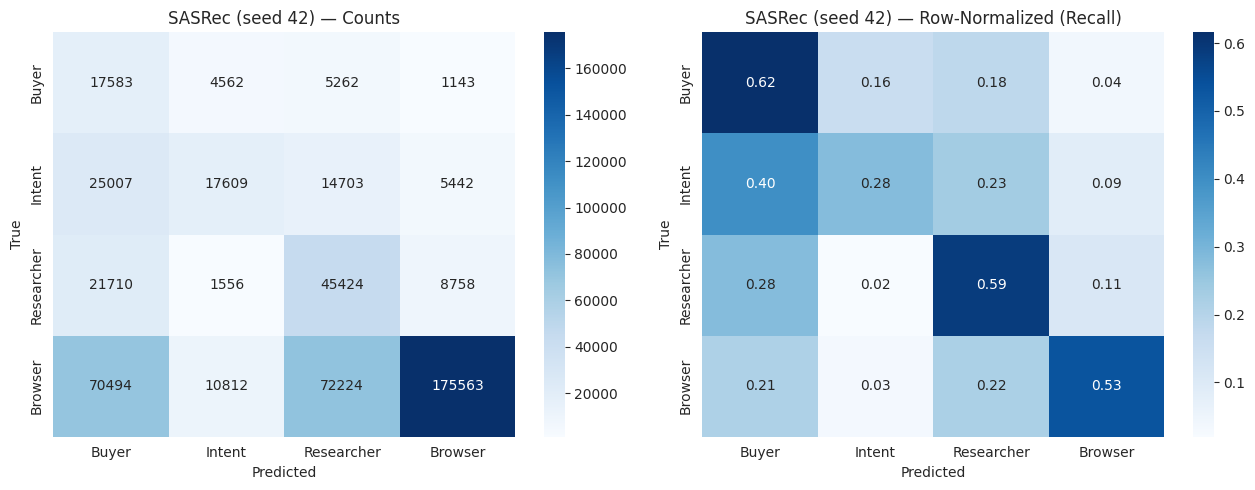

              precision    recall  f1-score   support

       Buyer     0.1304    0.6159    0.2153     28550
      Intent     0.5098    0.2806    0.3620     62761
  Researcher     0.3301    0.5865    0.4224     77448
     Browser     0.9196    0.5335    0.6752    329093

    accuracy                         0.5146    497852
   macro avg     0.4725    0.5041    0.4187    497852
weighted avg     0.7310    0.5146    0.5700    497852



In [ ]:
# -- 8.1 Overall confusion matrix (best SASRec, test split) --

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Select best seed by validation Macro-F1
best_run = max(seed_results, key=lambda r: r["best_val_f1"])
print(f"Best seed: {best_run['seed']} (val Macro-F1: {best_run['best_val_f1']:.4f})")

test_preds = best_run["test_preds"]
test_labels = best_run["test_labels"]
class_names = [idx2label[i] for i in range(4)]

cm_raw = confusion_matrix(test_labels, test_preds)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

# Plot side by side: raw counts and row-normalized (recall)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cm, title, fmt in [
    (axes[0], cm_raw, "Counts", "d"),
    (axes[1], cm_norm, "Row-Normalized (Recall)", ".2f"),
]:
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"SASRec (seed {best_run['seed']}) — {title}")

plt.tight_layout()
plt.show()

# Classification report
print(classification_report(test_labels, test_preds,
                            target_names=class_names, digits=4))

**Result (Overall Confusion Matrix):**

Test Macro-F1 = 0.4187 (seed 42). Per-class breakdown:

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Buyer | 0.1304 | 0.6159 | 0.2153 | 28,550 |
| Intent | 0.5098 | 0.2806 | 0.3620 | 62,761 |
| Researcher | 0.3301 | 0.5865 | 0.4224 | 77,448 |
| Browser | 0.9196 | 0.5335 | 0.6752 | 329,093 |

Key confusion patterns:

- **Buyer** has high recall (0.6159) but very low precision (0.1304), indicating many non-Buyer prefixes are predicted as Buyer (high false-positive rate).
- **Intent** remains difficult with low recall (0.2806) despite moderate precision (0.5098), many true Intent prefixes are predicted as other classes.
- **Researcher** shows strong recall (0.5865) but low precision (0.3301), consistent with substantial confusion between Researcher and other non-terminal behaviors (especially early prefixes).
- **Browser** has very high precision (0.9196) but only moderate recall (0.5335), meaning when the model predicts Browser it is usually correct, but many true Browser prefixes are misclassified into other classes.

In [ ]:
# -- 8.1 Per-class metrics by t (all models, test split) --

from sklearn.metrics import f1_score, precision_score, recall_score

# Add SASRec predictions to test prefix rows
test_mask = prefix_df["split"] == "test"

assert len(test_preds) == test_mask.sum(), \
    f"Mismatch: test_preds={len(test_preds)}, test rows={test_mask.sum()}"

prefix_df.loc[test_mask, "pred_sasrec"] = [idx2label[p] for p in test_preds]

# Models and their prediction columns
models = {
    "Majority": "pred_majority",
    "Heuristic": "pred_heuristic",
    "Markov": "pred_markov",
    "SASRec": "pred_sasrec",
}

# Verify all prediction columns exist
for name, col in models.items():
    assert col in prefix_df.columns, f"Missing column: {col}"

test_df = prefix_df[test_mask].copy()
t_values = sorted(test_df["t"].unique())
class_names = [idx2label[i] for i in range(4)]

# Compute metrics by t for each model
metrics_by_t = []

for t in t_values:
    t_slice = test_df[test_df["t"] == t]
    y_true = t_slice["label"]
    support = len(t_slice)

    for model_name, col in models.items():
        y_pred = t_slice[col]
        macro_f1 = f1_score(y_true, y_pred, labels=class_names,
                            average="macro", zero_division=0)
        per_class_p = precision_score(y_true, y_pred, labels=class_names,
                                      average=None, zero_division=0)
        per_class_r = recall_score(y_true, y_pred, labels=class_names,
                                   average=None, zero_division=0)
        per_class_f1 = f1_score(y_true, y_pred, labels=class_names,
                                average=None, zero_division=0)

        row = {"t": t, "model": model_name, "support": support, "macro_f1": macro_f1}
        for i, cls in enumerate(class_names):
            row[f"{cls}_precision"] = per_class_p[i]
            row[f"{cls}_recall"] = per_class_r[i]
            row[f"{cls}_f1"] = per_class_f1[i]
        metrics_by_t.append(row)

metrics_by_t = pd.DataFrame(metrics_by_t)

print(f"Computed metrics for {len(t_values)} t-values × {len(models)} models = {len(metrics_by_t)} rows")
print(f"t range: {t_values[0]}–{t_values[-1]}")

Computed metrics for 43 t-values × 4 models = 172 rows
t range: 1–43


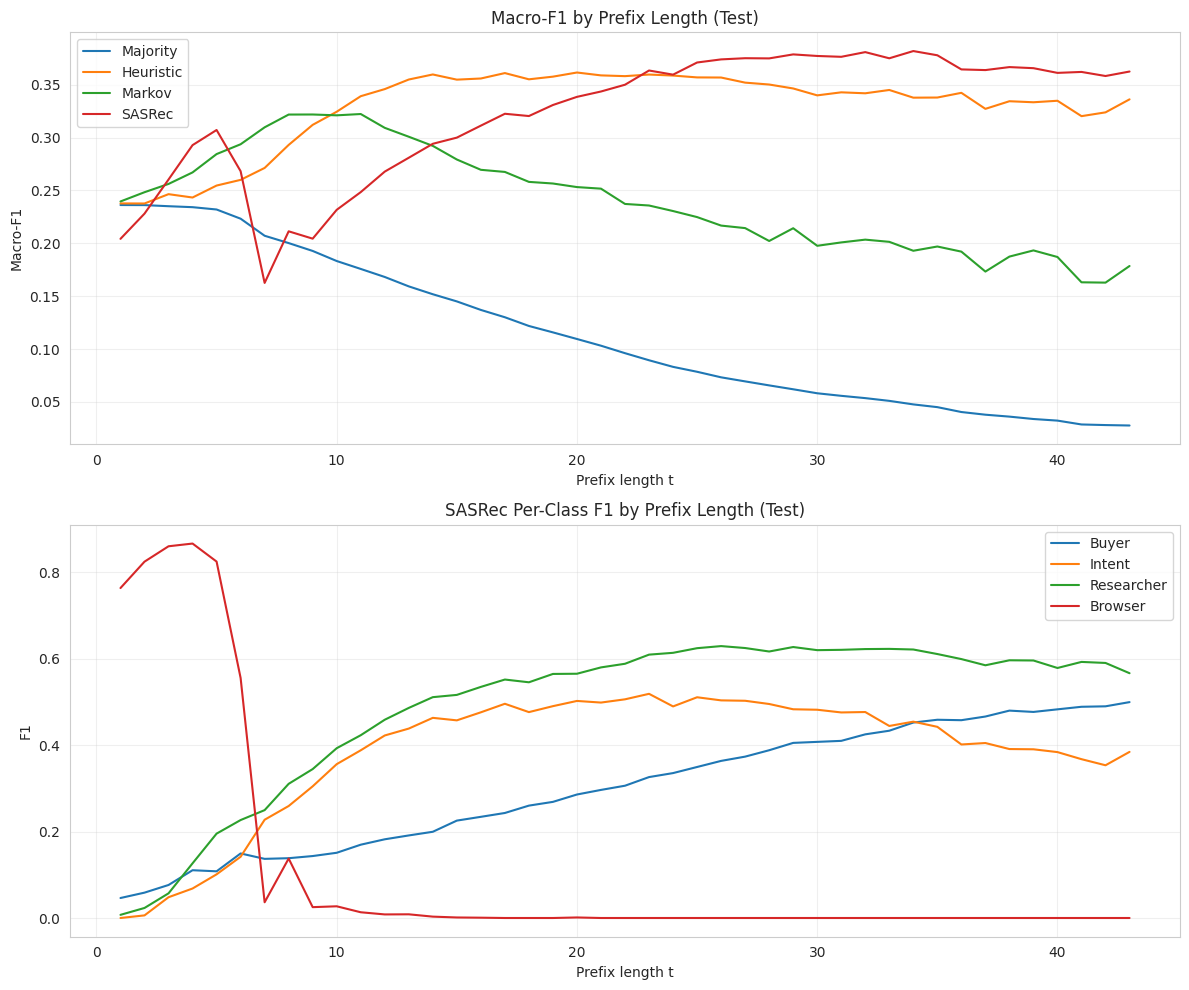

Support range: t=1 → 54,020,  t=43 → 2,136


In [ ]:
# -- 8.1 Macro-F1 by t (all models) and per-class F1 by t (SASRec) --

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Top: Macro-F1 by t, all models ---
ax = axes[0]
for model_name in models:
    m = metrics_by_t[metrics_by_t["model"] == model_name].sort_values("t")
    ax.plot(m["t"], m["macro_f1"], label=model_name, linewidth=1.5)
ax.set_xlabel("Prefix length t")
ax.set_ylabel("Macro-F1")
ax.set_title("Macro-F1 by Prefix Length (Test)")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Bottom: Per-class F1 by t, SASRec only ---
ax = axes[1]
sasrec_by_t = metrics_by_t[metrics_by_t["model"] == "SASRec"].sort_values("t")
for cls in class_names:
    ax.plot(sasrec_by_t["t"], sasrec_by_t[f"{cls}_f1"], label=cls, linewidth=1.5)
ax.set_xlabel("Prefix length t")
ax.set_ylabel("F1")
ax.set_title("SASRec Per-Class F1 by Prefix Length (Test)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Support by t (for context) ---
support_by_t = metrics_by_t[metrics_by_t["model"] == "SASRec"][["t", "support"]].sort_values("t")
print(f"Support range: t=1 → {support_by_t.iloc[0]['support']:,.0f},  "
      f"t=43 → {support_by_t.iloc[-1]['support']:,.0f}")

**Result (Metrics by Prefix Length):**

Support drops from 54,020 (t=1) to 2,136 (t=43) as fewer sessions reach longer prefixes.

**Macro-F1 by t (all models):**

- **SASRec** is non-monotonic at short t, it is lower at t=1 (about 0.20), rises to about 0.33 by t around 20 and about 0.36 by t around 25, then stays around 0.35-0.36 at late prefixes.
- **Heuristic** is strong in the mid-range, about 0.32 at t around 10, peaks around 0.35-0.36 at t around 15-25, then drifts down to about 0.33 by t around 40-43.
- **Markov(1)** peaks around t around 10 (about 0.31-0.32) and then steadily declines toward late prefixes (about 0.17 by t=43).
- **Majority** declines sharply as t grows (about 0.23 at t=1, down to about 0.05 by t around 30), reflecting the decreasing dominance of Browser-only behavior in longer prefixes.

**SASRec per-class F1 by t:**

- **Browser** is high at very short prefixes (about 0.76 at t=1, about 0.82 at t=5), then collapses by t around 10 (about 0.02) and is effectively absent at higher t where Browser support becomes negligible.
- **Researcher** increases strongly with t, reaching about 0.61 around t=25-30, then slightly declines by t around 35 (about 0.60).
- **Intent** rises quickly to about 0.49 around t=20-25, then declines by t around 35 (about 0.43).
- **Buyer** improves with more context (about 0.14 at t=10 to about 0.45 at t=35), but remains unstable overall (consistent with low Buyer precision in the overall confusion matrix).

## 8.2 Errors by Last Event Name

Analyze SASRec error rate grouped by `last_event_name` on the test split. For each unique `last_event_name` in test prefix rows, compute the error rate (`error = 1[y_pred != y_true]`, where `y_pred` is the SASRec prediction and `y_true` is the session class label) and support (number of prefix rows). This reveals which terminal events are systematically associated with classification errors and which carry strong discriminative signal.

In [ ]:
# -- 8.2 Error rate by last_event_name (SASRec, test split) --

test_df["sasrec_error"] = (test_df["pred_sasrec"] != test_df["label"]).astype(int)

error_by_last_event = (
    test_df.groupby("last_event_name", dropna=False)
    .agg(
        support=("sasrec_error", "size"),
        errors=("sasrec_error", "sum"),
    )
    .assign(error_rate=lambda x: x["errors"] / x["support"])
)

# Full table sorted by error rate
print("All last_event_name values sorted by error_rate (descending):")
print(error_by_last_event.sort_values("error_rate", ascending=False).to_string())
print()

# Top 10 by support (high-impact events)
print("Top 10 by support:")
print(error_by_last_event.sort_values("support", ascending=False).head(10).to_string())

All last_event_name values sorted by error_rate (descending):
                     support  errors  error_rate
last_event_name                                 
click                     79      67    0.848101
select_promotion        1269    1059    0.834515
view_search_results     3124    2234    0.715109
view_promotion         23728   15879    0.669209
user_engagement        96993   58899    0.607250
scroll                 57982   35141    0.606067
view_item              34499   19082    0.553117
begin_checkout          2163    1145    0.529357
add_shipping_info        870     444    0.510345
view_item_list             4       2    0.500000
page_view             176023   84849    0.482034
add_to_cart             4874    1860    0.381617
select_item             3750    1265    0.337333
session_start          52875   16501    0.312076
add_payment_info         413     122    0.295400
first_visit            39059    3124    0.079982
purchase                 147       0    0.000000

Top 10

**Errors by Last Event Name Result:**

17 unique `last_event_name` values in test. Key observations:

**Highest error rates (hardest last events):**

- **click** (84.8%, 79 prefixes) and **select_promotion** (83.5%, 1,269 prefixes) have the highest error rates, but low support (especially `click`), so they are not the main drivers by volume.
- **view_search_results** (71.5%, 3,124 prefixes) and **view_promotion** (66.9%, 23,728 prefixes) are highly ambiguous, promotion/search related actions occur across multiple session types.
- **user_engagement** (60.7%, 96,993 prefixes) and **scroll** (60.6%, 57,982 prefixes) are generic engagement events with weak class signal.
- **view_item** (55.3%, 34,499 prefixes) remains a major source of errors by volume (19,082 mispredictions).
- **begin_checkout** (52.9%, 2,163 prefixes) and **add_shipping_info** (51.0%, 870 prefixes) are ambiguous between Buyer and Intent outcomes.

**Lowest error rates (strong signal events):**

- **purchase** (0.0%, 147 prefixes), deterministic for Buyer.
- **first_visit** (8.0%, 39,059 prefixes), early-session event where Browser dominates.
- **session_start** (31.2%, 52,875 prefixes), relatively low compared to other high-support events.

**High-impact events (large support x high errors):**

- **page_view** (48.2%, 176,023 prefixes, 84,849 errors), **user_engagement** (60.7%, 96,993 prefixes, 58,899 errors), and **scroll** (60.6%, 57,982 prefixes, 35,141 errors) account for a large share of total errors. These generic navigational/engagement events carry limited class information and remain a primary bottleneck for overall performance.

## 8.3 Errors by Session Length

Analyze SASRec error rate grouped by session length on the test split. Each prefix row inherits the full `session_length` of its parent session. We bucket sessions into length ranges and compute error rate per bucket to identify whether short, medium, or long sessions are systematically harder to classify. Sessions exceeding Tmax (43) are grouped into a single bucket; for these sessions, the model observes only the first Tmax events, so this bucket reflects truncation effects.

Prefix rows with no bucket (NaN): 0

                       support  errors  n_sessions  error_rate
session_length_bucket                                         
1                          269     269         269    1.000000
2–3                      15454   10960        6351    0.709202
4–5                      85936   20133       18282    0.234279
6–10                    122342   40572       17530    0.331628
11–20                    89362   58727        6224    0.657181
21–43                    95393   59534        3292    0.624092
>43                      89096   51478        2072    0.577781


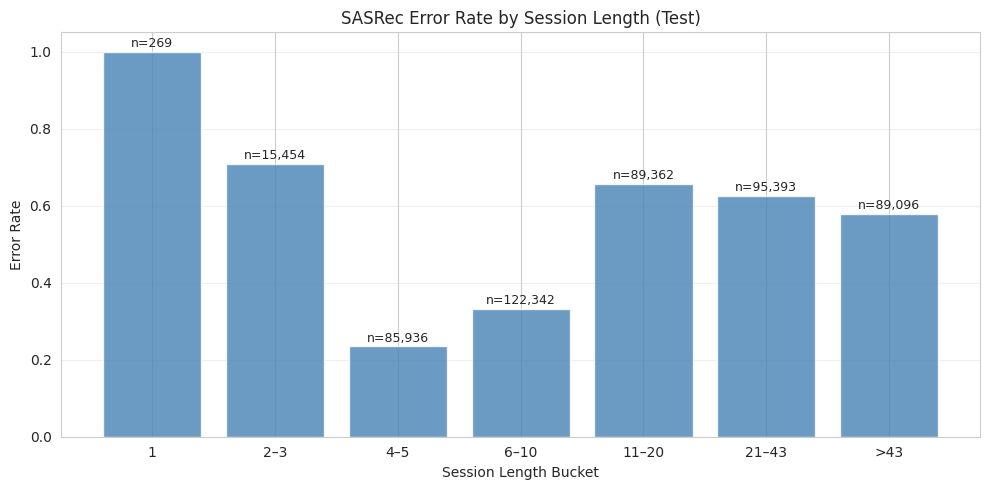

In [ ]:
# -- 8.3 Error rate by session_length buckets (SASRec, test split) --

# Define buckets: short sessions in detail, then coarser, then >Tmax
bins = [0, 1, 3, 5, 10, 20, 43, np.inf]
labels = ["1", "2–3", "4–5", "6–10", "11–20", "21–43", ">43"]

test_df["session_length_bucket"] = pd.cut(
    test_df["session_length"], bins=bins, labels=labels, right=True
)

# Safety check: no rows lost to NaN bucket
n_na = test_df["session_length_bucket"].isna().sum()
print(f"Prefix rows with no bucket (NaN): {n_na}")

error_by_length = (
    test_df.groupby("session_length_bucket", observed=True)
    .agg(
        support=("sasrec_error", "size"),
        errors=("sasrec_error", "sum"),
        n_sessions=("session_key", "nunique"),
    )
    .assign(error_rate=lambda x: x["errors"] / x["support"])
)

print()
print(error_by_length.to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(error_by_length))
ax.bar(x, error_by_length["error_rate"], color="steelblue", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(error_by_length.index)
ax.set_xlabel("Session Length Bucket")
ax.set_ylabel("Error Rate")
ax.set_title("SASRec Error Rate by Session Length (Test)")

# Add support labels on bars
for i, (rate, sup) in enumerate(zip(error_by_length["error_rate"], error_by_length["support"])):
    ax.text(i, rate + 0.005, f"n={sup:,}", ha="center", va="bottom", fontsize=9)

ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

**Errors by Session Length Result:**

No prefix rows lost to NaN buckets. Error rate is **not** monotonic with session length (it dips at 4-5 events, then rises for longer sessions):

| Bucket | Support | Sessions | Error Rate |
|---|---:|---:|---:|
| 1 | 269 | 269 | 100.0% |
| 2-3 | 15,454 | 6,351 | 70.9% |
| 4-5 | 85,936 | 18,282 | 23.4% |
| 6-10 | 122,342 | 17,530 | 33.2% |
| 11-20 | 89,362 | 6,224 | 65.7% |
| 21-43 | 95,393 | 3,292 | 62.4% |
| >43 | 89,096 | 2,072 | 57.8% |

Key observations:

- **Very short sessions (1-3 events)** are hardest here (70.9-100.0% error), indicating weak separability at extremely short prefixes under the current training setup.
- **Short sessions (4-5 events)** are the easiest bucket (23.4% error).
- **Medium sessions (6-20 events)** become substantially harder (33.2% -> 65.7%), consistent with higher class ambiguity in this range.
- **Long and truncated sessions (21-43, >43)** remain high-error (62.4%, 57.8%). Truncation at `Tmax=43` still limits visibility of late decisive actions in complex sessions.

## 8.4 N-Gram Error Patterns

Extract the last n events (n=2, 3, 4) from each test prefix and compute error rates by (n-gram pattern, true_class). This identifies specific event subsequences that systematically lead to mispredictions.

For each test prefix row, define the n-gram as the ordered tuple of the last n `event_name` tokens in the prefix (only if the prefix length `t >= n`). Then, for each (pattern, true_class) group, compute:

- `support`: number of prefix rows in the group
- `errors`: number of rows where `pred_sasrec != label`
- `error_rate = errors / support`

We report only groups with sufficient support to reduce noise (e.g., `support >= 100` for 2-grams, `>= 50` for 3-grams, `>= 20` for 4-grams), and focus on:

- high `error_rate` (systematic failure modes), and
- high `errors` (high-impact patterns by absolute mistake volume)

All computations are performed on the test split using the best SASRec run (seed 42) and prefix-row labels.

In [ ]:
# -- 8.4 N-gram error patterns (SASRec, test split) --

# Ensure sasrec_error exists (self-contained cell)
test_df["sasrec_error"] = (test_df["pred_sasrec"] != test_df["label"]).astype(int)

min_support = {2: 100, 3: 50, 4: 20}

ngram_results = {}

for n in [2, 3, 4]:
    mask = test_df["t"] >= n
    subset = test_df[mask].copy()

    # Extract last-n event names from session sequences
    keys = subset["session_key"].values
    ts = subset["t"].values

    patterns = []
    for sk, t in zip(keys, ts):
        seq = session_sequences[sk]
        tokens = seq[t - n : t]
        patterns.append(" → ".join(idx2event[tok] for tok in tokens))

    subset["ngram"] = patterns

    # Group by (pattern, true_class)
    grouped = (
        subset.groupby(["ngram", "label"], dropna=False)
        .agg(
            support=("sasrec_error", "size"),
            errors=("sasrec_error", "sum"),
        )
        .assign(error_rate=lambda x: x["errors"] / x["support"])
        .reset_index()
    )

    # Filter by minimum support
    grouped = grouped[grouped["support"] >= min_support[n]]
    ngram_results[n] = grouped

    print(f"=== {n}-grams (support >= {min_support[n]}) ===")
    print(f"Unique (pattern, class) groups: {len(grouped)}")

    # Top 10 by error_rate
    print(f"\nTop 10 by error_rate:")
    print(grouped.sort_values("error_rate", ascending=False).head(10)[
        ["ngram", "label", "support", "errors", "error_rate"]
    ].to_string(index=False))

    # Top 10 by absolute errors
    print(f"\nTop 10 by absolute errors:")
    print(grouped.sort_values("errors", ascending=False).head(10)[
        ["ngram", "label", "support", "errors", "error_rate"]
    ].to_string(index=False))

    print()

=== 2-grams (support >= 100) ===
Unique (pattern, class) groups: 169

Top 10 by error_rate:
                       ngram      label  support  errors  error_rate
add_payment_info → page_view     Intent      115     115         1.0
 first_visit → session_start Researcher      254     254         1.0
     page_view → first_visit     Intent      118     118         1.0
     page_view → first_visit Researcher      217     217         1.0
     first_visit → page_view     Intent      952     952         1.0
 first_visit → session_start     Intent      137     137         1.0
     first_visit → page_view      Buyer      206     206         1.0
     first_visit → page_view Researcher     1542    1542         1.0
   page_view → session_start Researcher     2352    2352         1.0
 user_engagement → view_item    Browser     1424    1424         1.0

Top 10 by absolute errors:
                           ngram      label  support  errors  error_rate
     user_engagement → page_view    Browser    2

## 8.5 Qualitative Error Examples

Select representative misclassified test prefix rows for the most frequent confusion pairs (true class → predicted class) under the best SASRec run (seed 42). The goal is to illustrate typical failure modes with concrete prefix trajectories, complementing the quantitative analyses in 8.1-8.4.

**Procedure** (prefix-row level):

- Identify the top confusion pairs by absolute error count from the overall test confusion matrix (excluding correct predictions).
- For each selected pair, sample a small, fixed number of prefix rows (e.g., 5-10) using a deterministic selection rule (e.g., fixed random seed or "first K after sorting by session_key, t") to ensure reproducibility.
- For each example, report: `session_key`, prefix length `t`, true class (`label`), predicted class (`pred_sasrec`), and the prefix event sequence as ordered `event_name` tokens (full prefix up to t, or last 15 events if prefix is long).

**Reporting focus:**

- Include examples from the dominant confusion directions observed earlier, especially Browser → Researcher, Browser → Buyer, Intent → Buyer, Researcher → Buyer, Intent → Researcher, and Browser → Intent.
- Prefer examples from high-support regions of `t` (e.g., `t=5-25`) to avoid cherry-picking rare long-prefix cases with low support.
- Where relevant, add brief qualitative notes (1-2 lines) linking each example to patterns found in 8.2 (`last_event_name`) and 8.4 (n-grams), without proposing fixes.

In [ ]:
# -- 8.5 Identify top confusion pairs by absolute error count --

from collections import Counter

# Count (true, pred) pairs for errors only
error_mask = test_df["label"] != test_df["pred_sasrec"]
error_pairs = list(zip(test_df.loc[error_mask, "label"], test_df.loc[error_mask, "pred_sasrec"]))
pair_counts = Counter(error_pairs)

# Top confusion pairs
print("Top 10 confusion pairs (true → pred) by error count:\n")
for (true_cls, pred_cls), count in pair_counts.most_common(10):
    print(f"  {true_cls:>12} → {pred_cls:<12}  {count:>6,} errors")

print(f"\nTotal misclassified prefix rows: {error_mask.sum():,} / {len(test_df):,}")

Top 10 confusion pairs (true → pred) by error count:

       Browser → Researcher    72,224 errors
       Browser → Buyer         70,494 errors
        Intent → Buyer         25,007 errors
    Researcher → Buyer         21,710 errors
        Intent → Researcher    14,703 errors
       Browser → Intent        10,812 errors
    Researcher → Browser        8,758 errors
        Intent → Browser        5,442 errors
         Buyer → Researcher     5,262 errors
         Buyer → Intent         4,562 errors

Total misclassified prefix rows: 241,673 / 497,852


In [ ]:
# -- 8.5 Sample qualitative error examples for top confusion pairs --

# Select top 6 confusion pairs by volume
top_pairs = [pair for pair, _ in pair_counts.most_common(6)]

n_examples = 5
max_display_events = 15

errors_df = test_df[error_mask].copy()

for true_cls, pred_cls in top_pairs:
    pair_mask = (errors_df["label"] == true_cls) & (errors_df["pred_sasrec"] == pred_cls)
    total_pair_errors = pair_mask.sum()
    pair_df = errors_df[pair_mask]

    # Filter to t=5–25 for high-support region
    pair_df = pair_df[(pair_df["t"] >= 5) & (pair_df["t"] <= 25)]

    if len(pair_df) == 0:
        print(f"\n{'='*60}")
        print(f"{true_cls} → {pred_cls}: no examples in t=5–25")
        continue

    # Deterministic sample
    sample = pair_df.sample(n=min(n_examples, len(pair_df)), random_state=42)
    sample = sample.sort_values(["session_key", "t"])

    print(f"\n{'='*60}")
    print(f"{true_cls} → {pred_cls}  ({total_pair_errors:,} total errors, "
          f"{len(pair_df):,} in t=5–25)")
    print(f"{'='*60}")

    for _, row in sample.iterrows():
        sk = row["session_key"]
        t = int(row["t"])

        assert sk in session_sequences, f"Missing session_key: {sk}"
        assert t <= len(session_sequences[sk]), f"t={t} > seq len={len(session_sequences[sk])}"

        seq = session_sequences[sk][:t]
        events = [idx2event[tok] for tok in seq]

        # Show last max_display_events if prefix is long
        if len(events) > max_display_events:
            display = "... → " + " → ".join(events[-max_display_events:])
        else:
            display = " → ".join(events)

        print(f"\n  session_key: {sk}")
        print(f"  t={t}, true={true_cls}, pred={pred_cls}")
        print(f"  prefix: {display}")


Browser → Researcher  (72,224 total errors, 64,763 in t=5–25)

  session_key: 3308186.3799262840_3821566781
  t=6, true=Browser, pred=Researcher
  prefix: page_view → session_start → page_view → scroll → page_view → scroll

  session_key: 57489867.8681916787_6271841438
  t=6, true=Browser, pred=Researcher
  prefix: first_visit → page_view → session_start → page_view → scroll → page_view

  session_key: 70512719.7857857136_6223873613
  t=12, true=Browser, pred=Researcher
  prefix: first_visit → page_view → session_start → page_view → scroll → user_engagement → page_view → scroll → user_engagement → page_view → scroll → user_engagement

  session_key: 797089160.7075375688_1511085078
  t=8, true=Browser, pred=Researcher
  prefix: first_visit → page_view → session_start → page_view → scroll → user_engagement → scroll → page_view

  session_key: 84398682.6562043976_6515131076
  t=15, true=Browser, pred=Researcher
  prefix: first_visit → page_view → session_start → page_view → scroll → user

**8.5 Result:**

Six dominant confusion pairs examined (5 examples each, t=5-25). Key patterns:

**Browser -> Researcher** (72,224 errors, 64,763 in t=5-25, largest pair):
Prefixes are dominated by navigational/engagement events (`page_view`, `scroll`, `user_engagement`) and often include the recurring `page_view -> session_start -> page_view` pattern. In sampled examples, there are no clear product or cart signals, yet the model predicts Researcher. This matches the overall pattern of low Researcher precision and reduced Browser recall at mid-prefixes.

**Browser -> Buyer** (70,494 errors, 27,184 in t=5-25):
Prefixes are mostly navigation plus promotion exposure (`view_promotion`) with engagement events. With no purchase/checkout evidence in the prefix, the model still predicts Buyer, consistent with the overall confusion matrix where Buyer has very low precision (many false positives).

**Intent -> Buyer** (25,007 errors, 11,681 in t=5-25):
Some prefixes include clear cart activity (`add_to_cart`) and item interactions, but purchase is not yet observed. The model predicts Buyer prematurely, a future-dependent confusion where the Buyer-defining evidence typically appears late.

**Researcher -> Buyer** (21,710 errors, 11,291 in t=5-25):
Prefixes mix navigation/engagement with occasional product interactions (`view_item`, sometimes repeated) and promotions. Without late decisive actions, the model often jumps to Buyer, again reflecting the strong Buyer overprediction mode.

**Intent -> Researcher** (14,703 errors, 11,466 in t=5-25):
Prefixes contain item interactions (`view_item`, `select_item`) but lack cart/checkout signals at the observed t. The model selects Researcher as the closest "product-interaction heavy" class, even though cart actions may occur later.

**Browser -> Intent** (10,812 errors, 10,566 in t=5-25):
Prefixes often show promotion exposure and occasional item interactions, but no cart/checkout yet. The model predicts Intent based on weak early cues, even when the session label remains Browser (below the Researcher threshold and without cart actions).

**Common thread:** dominant error modes remain future-dependent, the defining evidence for Buyer (purchase), Intent (cart/checkout), and Researcher (accumulated product interactions) often has not occurred within the prefix window. Meanwhile, early and mid prefixes are dominated by generic navigational events, limiting separability.

**Data artifact note:** the recurring `page_view -> session_start -> page_view` and `first_visit -> page_view -> session_start` patterns appear across multiple confusion pairs, supporting the earlier observation that mid-sequence `session_start` may reflect ordering artifacts in the GA4 export rather than meaningful behavior.

**Section 8 Summary:**

- **Overall:** SASRec (seed 42) achieves test Macro-F1 = 0.4187. Buyer is the hardest class (F1 0.2153) and is heavily overpredicted (precision 0.1304). Browser remains the easiest class by F1 (0.6752) but has only moderate recall (0.5335), indicating substantial confusion of true Browser prefixes into other classes.
- **By prefix length (8.1):** SASRec does not consistently dominate all baselines across t=1-43. Heuristic is competitive in the mid-range (t around 15-25). Markov(1) peaks around t around 10 and then degrades toward late prefixes as last events become increasingly generic. Minority-class F1 generally improves with t, but remains unstable, and Browser becomes less informative at higher t where its support is small.
- **By last event (8.2):** Deterministic events (`purchase`) yield 0% error. Generic engagement/navigation events produce high error rates and large error volumes, especially `page_view` (48.2% error, 84,849 errors), `user_engagement` (60.7% error, 58,899 errors), and `scroll` (60.6% error, 35,141 errors). `view_item` remains highly ambiguous (55.3% error, 19,082 errors). Checkout-adjacent events (`begin_checkout`, `add_shipping_info`) stay around 51-53% error.
- **By session length (8.3):** Error rate is not monotonic. Very short sessions (1-3 events) have extremely high error (70.9-100.0%), the lowest error occurs at 4-5 events (23.4%), and longer sessions remain high-error (57.8-65.7%), including truncated sessions capped at `Tmax=43`.
- **Qualitative examples (8.5):** Dominant confusion pairs are driven by future-dependent class identity and weak early evidence. The largest pair is Browser -> Researcher (72,224 errors, 64,763 within t=5-25). Buyer overprediction is also a major mode (Browser -> Buyer: 70,494 errors). Across pairs, early and mid prefixes are dominated by generic navigational events, limiting separability.
- **Implication for future work:** with session-level class weighting, sequence-only models show a substantially lower ceiling in this run. The remaining bottleneck appears to be both *information availability* (event types alone) and *class separability* at short prefixes, suggesting that richer signals (timing, context, engineered features) are required to improve early discrimination.

# 9. Reporting and Reproducibility

This section exports all key artifacts from the experiment for reproducibility and external review. Artifacts include updated datasets with model predictions, aggregated metrics, model configuration, and environment details.



## 9.1 Export Artifacts

Save the following files:

- `prefix_level_with_preds.csv` — prefix dataset with SASRec predictions and error flags (new file, original `prefix_level.csv` preserved)
- `seed_results_summary.csv` — per-seed training results
- `metrics_overall.json` — val/test Macro-F1 for all models and best seed info
- `metrics_by_t.csv` — per-class metrics by prefix length t for all models (from 8.1)
- `config.json` — full experiment configuration (hyperparameters, Tmax, vocab, class weights, seeds)

In [ ]:
# -- 9.1 Save prefix_level_with_preds.csv --

# Rebuild test_df with predictions (from Section 8)
test_mask = prefix_df["split"] == "test"
test_df = prefix_df[test_mask].copy()

best_run = max(seed_results, key=lambda r: r["best_val_f1"])
assert len(best_run["test_preds"]) == len(test_df), \
    f"Mismatch: preds={len(best_run['test_preds'])}, test rows={len(test_df)}"

test_df["pred_sasrec"] = [idx2label[p] for p in best_run["test_preds"]]
test_df["sasrec_error"] = (test_df["pred_sasrec"] != test_df["label"]).astype(int)

# Merge back by unique key (session_key, t, split)
assert test_df.duplicated(subset=["session_key", "t", "split"]).sum() == 0, \
    "Key (session_key, t, split) is not unique in test_df"

preds_to_merge = test_df[["session_key", "t", "split", "pred_sasrec", "sasrec_error"]]

# Drop any existing sasrec columns (handles _x/_y variants from previous runs)
sasrec_cols = [c for c in prefix_df.columns if "pred_sasrec" in c or "sasrec_error" in c]
prefix_export = prefix_df.drop(columns=sasrec_cols)
prefix_export = prefix_export.merge(preds_to_merge, on=["session_key", "t", "split"], how="left")

prefix_export.to_csv("prefix_level_with_preds.csv", index=False)

print(f"Saved prefix_level_with_preds.csv: {len(prefix_export):,} rows, {len(prefix_export.columns)} columns")
print(f"Columns: {list(prefix_export.columns)}")
print(f"pred_sasrec non-null: {prefix_export['pred_sasrec'].notna().sum():,} (test rows only)")

Saved prefix_level_with_preds.csv: 3,325,933 rows, 12 columns
Columns: ['session_key', 'split', 't', 'last_event_name', 'session_length', 'label', 'prefix_pi_count', 'pred_heuristic', 'pred_markov', 'pred_majority', 'pred_sasrec', 'sasrec_error']
pred_sasrec non-null: 497,852 (test rows only)


In [ ]:
# -- 9.1 Save seed_results_summary.csv --

seed_summary = pd.DataFrame([
    {"seed": r["seed"], "best_val_f1": r["best_val_f1"], "test_f1": r["test_f1"]}
    for r in seed_results
])

seed_summary.to_csv("seed_results_summary.csv", index=False)

print("Saved seed_results_summary.csv:")
print(seed_summary.to_string(index=False))

Saved seed_results_summary.csv:
 seed  best_val_f1  test_f1
   42     0.406541 0.418728
  123     0.402896 0.416521
  456     0.403304 0.417534


In [ ]:
# -- 9.1 Save metrics_overall.json --

import json
from sklearn.metrics import f1_score

# Compute val/test Macro-F1 for all models
models_eval = {
    "Majority": "pred_majority",
    "Heuristic": "pred_heuristic",
    "Markov": "pred_markov",
}

class_names = [idx2label[i] for i in range(4)]
metrics_overall = {}

for model_name, col in models_eval.items():
    for split_name in ["val", "test"]:
        split_df = prefix_df[prefix_df["split"] == split_name]
        f1 = f1_score(split_df["label"], split_df[col],
                      labels=class_names, average="macro", zero_division=0)
        metrics_overall.setdefault(model_name, {})[f"{split_name}_macro_f1"] = round(f1, 4)

# SASRec: use best seed
best_run = max(seed_results, key=lambda r: r["best_val_f1"])
metrics_overall["SASRec"] = {
    "val_macro_f1": round(best_run["best_val_f1"], 4),
    "test_macro_f1": round(best_run["test_f1"], 4),
    "best_seed": best_run["seed"],
    "mean_test_f1": round(np.mean([r["test_f1"] for r in seed_results]), 4),
    "std_test_f1": round(np.std([r["test_f1"] for r in seed_results], ddof=1), 4),
}

with open("metrics_overall.json", "w") as f:
    json.dump(metrics_overall, f, indent=2)

print("Saved metrics_overall.json:")
print(json.dumps(metrics_overall, indent=2))

Saved metrics_overall.json:
{
  "Majority": {
    "val_macro_f1": 0.2078,
    "test_macro_f1": 0.199
  },
  "Heuristic": {
    "val_macro_f1": 0.3854,
    "test_macro_f1": 0.3761
  },
  "Markov": {
    "val_macro_f1": 0.3298,
    "test_macro_f1": 0.3186
  },
  "SASRec": {
    "val_macro_f1": 0.4065,
    "test_macro_f1": 0.4187,
    "best_seed": 42,
    "mean_test_f1": 0.4176,
    "std_test_f1": 0.0011
  }
}


In [ ]:
# -- 9.1 Save metrics_by_t.csv --

metrics_by_t.to_csv("metrics_by_t.csv", index=False)

print(f"Saved metrics_by_t.csv: {len(metrics_by_t)} rows, {len(metrics_by_t.columns)} columns")
print(f"Models: {metrics_by_t['model'].unique().tolist()}")
print(f"t range: {metrics_by_t['t'].min()}–{metrics_by_t['t'].max()}")

Saved metrics_by_t.csv: 172 rows, 16 columns
Models: ['Majority', 'Heuristic', 'Markov', 'SASRec']
t range: 1–43


In [ ]:
# -- 9.1 Save config.json --

config_export = {
    **config,
    "Tmax": int(tmax),
    "vocab_size": len(event2idx),
    "class_weights": [round(w, 4) for w in class_weights.tolist()],
    "label_mapping": label2idx,
    "event_vocab": event2idx,
    "n_classes": 4,
    "alpha_smoothing": 0.01,
    "split_ratios": "70/15/15 temporal by session_end_time",
}

with open("config.json", "w") as f:
    json.dump(config_export, f, indent=2)

print("Saved config.json:")
print(json.dumps(config_export, indent=2))

Saved config.json:
{
  "max_len": 43,
  "embedding_dim": 64,
  "n_layers": 2,
  "n_heads": 2,
  "dropout": 0.1,
  "lr": 0.001,
  "epochs": 20,
  "patience": 3,
  "batch_size": 256,
  "seeds": [
    42,
    123,
    456
  ],
  "imbalance": "class_weights",
  "Tmax": 43,
  "vocab_size": 19,
  "class_weights": [
    16.6462,
    5.3875,
    4.3285,
    0.2838
  ],
  "label_mapping": {
    "Buyer": 0,
    "Intent": 1,
    "Researcher": 2,
    "Browser": 3
  },
  "event_vocab": {
    "PAD": 0,
    "UNK": 1,
    "add_payment_info": 2,
    "add_shipping_info": 3,
    "add_to_cart": 4,
    "begin_checkout": 5,
    "click": 6,
    "first_visit": 7,
    "page_view": 8,
    "purchase": 9,
    "scroll": 10,
    "select_item": 11,
    "select_promotion": 12,
    "session_start": 13,
    "user_engagement": 14,
    "view_item": 15,
    "view_item_list": 16,
    "view_promotion": 17,
    "view_search_results": 18
  },
  "n_classes": 4,
  "alpha_smoothing": 0.01,
  "split_ratios": "70/15/15 temporal by

**Result:**

Exported 7 artifact files:

- `prefix_level_with_preds.csv` - full prefix dataset with `pred_sasrec` and `sasrec_error` columns (test rows only, NaN for train/val)
- `seed_results_summary.csv` - per-seed best val Macro-F1 and test Macro-F1
- `metrics_overall.json` - val/test Macro-F1 for all 4 models, best seed info, mean ± std across seeds
- `metrics_by_t.csv` - per-class Precision/Recall/F1 and Macro-F1 by prefix length t for all models (172 rows)
- `config.json` - full experiment configuration: hyperparameters, Tmax, vocabulary, class weights, label mapping, smoothing alpha, split strategy
- `run_manifest.json` - run metadata snapshot (timestamps, environment info, key settings)
- `requirements.txt` - Python package versions captured for reproducibility

## 9.2 Run Manifest and Environment

Save environment details and frozen library versions for full reproducibility.

In [ ]:
# -- 9.2 Save run_manifest.json --

import sys
import datetime
import sklearn

manifest = {
    "run_date": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "python_version": sys.version,
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A",
    "sklearn_version": sklearn.__version__,
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "seeds": config["seeds"],
    "best_seed": int(best_run["seed"]),
    "data_source": "bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*",
    "gcp_project_id": "ga4sb-487512",
}

with open("run_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print("Saved run_manifest.json:")
print(json.dumps(manifest, indent=2))

Saved run_manifest.json:
{
  "run_date": "2026-02-27 17:51:03",
  "python_version": "3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]",
  "torch_version": "2.10.0+cpu",
  "cuda_available": false,
  "cuda_device": "N/A",
  "sklearn_version": "1.6.1",
  "pandas_version": "2.2.2",
  "numpy_version": "2.0.2",
  "seeds": [
    42,
    123,
    456
  ],
  "best_seed": 42,
  "data_source": "bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*",
  "gcp_project_id": "ga4sb-487512"
}


In [ ]:
# -- 9.2 Save requirements.txt --
import subprocess

result = subprocess.run(["pip", "freeze"], capture_output=True, text=True)

with open("requirements.txt", "w") as f:
    f.write(result.stdout)

n_packages = len(result.stdout.strip().split("\n"))
print(f"Saved requirements.txt: {n_packages} packages")
print("\nKey packages:")
for pkg in ["torch", "scikit-learn", "pandas", "numpy", "matplotlib"]:
    for line in result.stdout.split("\n"):
        if line.lower().startswith(pkg):
            print(f"  {line}")
            break

Saved requirements.txt: 662 packages

Key packages:
  torch @ https://download.pytorch.org/whl/cpu/torch-2.10.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl
  scikit-learn==1.6.1
  pandas==2.2.2
  numpy==2.0.2
  matplotlib==3.10.0


**Result:**

Exported 2 environment files:

- `run_manifest.json` — run date, Python/torch/sklearn/pandas/numpy versions, CUDA device, seeds, data source
- `requirements.txt` — full frozen pip package list for environment replication

**Section 9 Summary:**

Exported 7 artifact files for full experiment reproducibility:

| File | Description |
|---|---|
| `prefix_level_with_preds.csv` | Prefix dataset with SASRec predictions and error flags |
| `seed_results_summary.csv` | Per-seed val/test Macro-F1 |
| `metrics_overall.json` | All models val/test Macro-F1, best seed, mean ± std |
| `metrics_by_t.csv` | Per-class metrics by prefix length t, all models |
| `config.json` | Hyperparameters, Tmax, vocabulary, class weights, split strategy |
| `run_manifest.json` | Run date, Python/library versions, CUDA device, data source |
| `requirements.txt` | Frozen pip packages |

Together with the previously saved `event_level.csv`, `session_level.csv`, and `prefix_level.csv`, this provides a complete artifact package for replicating or extending the experiment.



---

